# Fairness Baseline and Mitigation Methods
### From Stage to System: Bias Propagation in Clinical AI Pipelines
**Hilina Fissha Woreta**

**Luwam Major Kefali**

This notebook measures the baseline bias in the clinical pipeline and tests five fairness mitigation methods -- four established ones plus a pipeline-aware hybrid we built ourselves. The goal is to see how much each method improves fairness, what it costs in accuracy, and whether the improvement actually holds across the full pipeline.


## Setup

Loading the preprocessed data splits, the trained Stage 2 model, the calibrator, and the Stage 3 enrollment results from the previous notebooks.

In [1]:
import numpy as np
import pandas as pd
import pickle
import json
import warnings
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.isotonic import IsotonicRegression
from sklearn.utils.class_weight import compute_sample_weight

random_seed = 42

warnings.filterwarnings(
    "ignore",
    message=".*Setting an item of incompatible dtype.*",
    category=FutureWarning,
)

pre_dir = "/kaggle/input/notebooks/hilinafissha16/preprocessing"
clf_dir = "/kaggle/input/notebooks/hilinafissha16/readmission-risk-classifier"

train = pd.read_parquet(f"{pre_dir}/splits/train.parquet")
val   = pd.read_parquet(f"{pre_dir}/splits/val.parquet")
test  = pd.read_parquet(f"{pre_dir}/splits/test.parquet")

with open(f"{clf_dir}/stage2_model.pkl", "rb") as f:
    model = pickle.load(f)

with open(f"{clf_dir}/stage2_calibrator.pkl", "rb") as f:
    calibrator = pickle.load(f)

with open(f"{clf_dir}/stage2_best_params.json") as f:
    best_params = json.load(f)

with open(f"{clf_dir}/stage2_encodings.json") as f:
    encodings = json.load(f)

stage3 = pd.read_parquet(f"{clf_dir}/stage3_results.parquet")

print("train:", train.shape)
print("val:  ", val.shape)
print("test: ", test.shape)
print("\nstage 3 baseline results:", stage3.shape)
print("\nloaded best_params:", best_params)
print("loaded encodings keys:", list(encodings.keys()))

train: (279569, 43)
val:   (60391, 43)
test:  (59409, 43)

stage 3 baseline results: (60391, 5)

loaded best_params: {'n_estimators': 544, 'learning_rate': 0.018202984573927, 'max_depth': 8, 'subsample': 0.6343026862233081, 'colsample_bytree': 0.8531100620564094, 'min_child_weight': 6}
loaded encodings keys: ['race', 'insurance', 'admission_type']


## Feature preparation

Setting up the feature columns the same way as in the classifier notebook. This needs to be consistent across notebooks so the model receives the same inputs.

In [2]:
cols_to_drop = [
    "subject_id", "hadm_id", "admittime", "dischtime",
    "readmitted_30d", "race_x_sex", "race_x_insurance",
    "race_clean", "insurance_clean", "sex", "admission_type",
    "hospital_expire_flag"
]

RACE_TO_ENC = encodings["race"]
RACES       = sorted(RACE_TO_ENC, key=RACE_TO_ENC.get)
INS_TO_ENC  = encodings["insurance"]
INS_GROUPS  = sorted(INS_TO_ENC, key=INS_TO_ENC.get)
ADMISSION_TO_ENC = encodings["admission_type"]

print("race encoding:", RACE_TO_ENC)
print("insurance encoding:", INS_TO_ENC)
print("admission type encoding:", ADMISSION_TO_ENC)

for df in [train, val, test]:
    df["sex_enc"]            = df["sex"].map({"Male": 0, "Female": 1}).fillna(-1)
    df["race_enc"]           = df["race_clean"].map(RACE_TO_ENC).fillna(-1).astype(int)
    df["insurance_enc"]      = df["insurance_clean"].map(INS_TO_ENC).fillna(-1).astype(int)
    df["admission_type_enc"] = df["admission_type"].map(ADMISSION_TO_ENC).fillna(-1).astype(int)

feature_cols = [c for c in train.columns if c not in cols_to_drop]
feature_cols = list(dict.fromkeys(feature_cols))
target = "readmitted_30d"

x_train = train[feature_cols]
y_train = train[target]
x_val   = val[feature_cols]
y_val   = val[target]
x_test  = test[feature_cols]
y_test  = test[target]

print("\nfeatures:", len(feature_cols))

race encoding: {'Asian': 0, 'Black/African American': 1, 'Hispanic/Latino': 2, 'Other/Unknown': 3, 'White': 4}
insurance encoding: {'Medicaid': 0, 'Medicare': 1, 'Other': 2, 'Private': 3}
admission type encoding: {'AMBULATORY OBSERVATION': 0, 'DIRECT EMER.': 1, 'DIRECT OBSERVATION': 2, 'ELECTIVE': 3, 'EU OBSERVATION': 4, 'EW EMER.': 5, 'OBSERVATION ADMIT': 6, 'SURGICAL SAME DAY ADMISSION': 7, 'URGENT': 8}

features: 35


## Baseline fairness measurement

Before trying to fix anything, we need to know exactly how unfair the pipeline already is. We measure three things per racial group:

- **Enrollment rate** -- what fraction of patients from each group got enrolled in the care program
- **TPR (True Positive Rate)** -- of patients who actually got readmitted, what fraction got correctly enrolled
- **FPR (False Positive Rate)** -- of patients who were not readmitted, what fraction got enrolled anyway

We then compute the **demographic parity ratio**: the lowest enrollment rate divided by the highest. A score of 1.0 means perfect parity across groups. Lower means more disparity.

In [3]:
def compute_fairness_metrics(df, group_col, enrolled_col, outcome_col):
    results = []
    for group in df[group_col].unique():
        subset       = df[df[group_col] == group]
        readmitted   = subset[subset[outcome_col] == 1]
        not_readmit  = subset[subset[outcome_col] == 0]
        results.append({
            "group":           group,
            "n":               len(subset),
            "enrollment_rate": round(subset[enrolled_col].mean(), 3),
            "tpr":             round(readmitted[enrolled_col].mean(), 3) if len(readmitted) > 0 else 0,
            "fpr":             round(not_readmit[enrolled_col].mean(), 3) if len(not_readmit) > 0 else 0,
        })
    return pd.DataFrame(results).sort_values("enrollment_rate", ascending=False)

baseline_metrics = compute_fairness_metrics(stage3, "race_clean", "enrolled", "y_true")

min_rate = baseline_metrics["enrollment_rate"].min()
max_rate = baseline_metrics["enrollment_rate"].max()
dp_ratio = min_rate / max_rate

print("baseline fairness metrics by race:")
print(baseline_metrics.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio:.3f}")

metrics_excl = baseline_metrics[baseline_metrics["group"] != "Other/Unknown"]
dp_ratio_excl = metrics_excl["enrollment_rate"].min() / metrics_excl["enrollment_rate"].max()
print(f"\nsensitivity check — dp_ratio excluding Other/Unknown: {dp_ratio_excl:.3f}")

baseline fairness metrics by race:
                 group     n  enrollment_rate   tpr   fpr
Black/African American  9102            0.139 0.316 0.085
       Hispanic/Latino  3097            0.122 0.283 0.074
                 Asian  2008            0.101 0.252 0.059
                 White 41320            0.097 0.224 0.063
         Other/Unknown  4864            0.050 0.196 0.027

demographic parity ratio: 0.360

sensitivity check — dp_ratio excluding Other/Unknown: 0.698


In [4]:
baseline_metrics.to_parquet("/kaggle/working/baseline_fairness_metrics.parquet", index=False)

In [5]:
def compute_cfvr(score_fn, df, threshold):
    orig_scores   = score_fn(df)
    orig_enrolled = (orig_scores >= threshold).astype(int)
    any_flip = np.zeros(len(df), dtype=int)
    for race in RACES:
        mask = (df["race_clean"].values != race)
        if mask.sum() == 0:
            continue
        cf = df.copy()
        cf.loc[cf.index[mask], "race_clean"] = race
        cf.loc[cf.index[mask], "race_enc"]   = RACE_TO_ENC[race]
        cf_scores   = score_fn(cf)
        cf_enrolled = (cf_scores >= threshold).astype(int)
        flipped = ((cf_enrolled != orig_enrolled) & mask).astype(int)
        any_flip = np.maximum(any_flip, flipped)
    cfvr_val = round(float(any_flip.mean()), 4)
    breakdown = (
        df[["race_clean"]].copy()
        .assign(flipped=any_flip)
        .groupby("race_clean")["flipped"].mean()
        .round(4).reset_index()
        .rename(columns={"flipped": "cfvr"})
    )
    return cfvr_val, breakdown

def cfvr_binary(predict_fn, df):
    orig_enrolled = predict_fn(df)
    any_flip = np.zeros(len(df), dtype=int)
    for race in RACES:
        mask = (df["race_clean"].values != race)
        if mask.sum() == 0:
            continue
        cf = df.copy()
        cf.loc[cf.index[mask], "race_clean"] = race
        cf.loc[cf.index[mask], "race_enc"]   = RACE_TO_ENC[race]
        cf_enrolled = predict_fn(cf)
        flipped = ((cf_enrolled != orig_enrolled) & mask).astype(int)
        any_flip = np.maximum(any_flip, flipped)
    cfvr_val = round(float(any_flip.mean()), 4)
    breakdown = (
        df[["race_clean"]].copy()
        .assign(flipped=any_flip)
        .groupby("race_clean")["flipped"].mean()
        .round(4).reset_index()
        .rename(columns={"flipped": "cfvr"})
    )
    return cfvr_val, breakdown

In [6]:
base_scores_val = calibrator.predict(model.predict_proba(val[feature_cols])[:, 1])
threshold_base  = pd.Series(base_scores_val).quantile(0.90)

auroc_base = roc_auc_score(y_val, base_scores_val)
print(f"baseline AUROC: {auroc_base:.4f}")

def score_fn_base(df):
    return calibrator.predict(model.predict_proba(df[feature_cols])[:, 1])

cfvr_base, cfvr_base_bd = compute_cfvr(score_fn_base, val, threshold_base)
print(f"\nbaseline CFVR: {cfvr_base}")
print("\nby race:")
print(cfvr_base_bd.to_string(index=False))

baseline AUROC: 0.7017

baseline CFVR: 0.0202

by race:
            race_clean   cfvr
                 Asian 0.0184
Black/African American 0.0290
       Hispanic/Latino 0.0207
         Other/Unknown 0.0169
                 White 0.0187


## Method 1: Reweighting

The idea here is simple. Minority patients are underrepresented in the training data, so the model doesn't learn as much about them. Reweighting fixes this by assigning a higher importance score to each minority patient during training.

We create a combined label of race and readmission outcome, then use sklearn's `compute_sample_weight` to calculate how much each patient should count. Asian patients get the highest weight since they're the smallest group. White patients get the lowest since they're the majority.

The model then trains on the same data but treats minority patients as more important.

In [7]:
def compute_reweighting(df, group_col, target_col):
    group_target = df[group_col] + "_" + df[target_col].astype(str)
    return compute_sample_weight(class_weight="balanced", y=group_target)

train_weights = compute_reweighting(train, "race_clean", "readmitted_30d")

temp = train[["race_clean"]].copy()
temp["weight"] = train_weights
print("mean weight by race:")
print(temp.groupby("race_clean")["weight"].mean().round(3).sort_values(ascending=False).to_string())

mean weight by race:
race_clean
Asian                     6.206
Hispanic/Latino           3.859
Other/Unknown             2.552
Black/African American    1.360
White                     0.290


Training the reweighted model with the same hyperparameters as the baseline.

In [8]:
model_rw = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=random_seed,
    eval_metric="auc",
    early_stopping_rounds=20,
    verbosity=1
)

model_rw.fit(
    x_train, y_train,
    sample_weight=train_weights,
    eval_set=[(x_val, y_val)],
    verbose=50
)

val_preds_rw = model_rw.predict_proba(x_val)[:, 1]
val_auc_rw   = roc_auc_score(y_val, val_preds_rw)
print(f"reweighted model AUROC: {val_auc_rw:.4f}")
print(f"baseline was:           {auroc_base:.4f}")

[0]	validation_0-auc:0.61569
[50]	validation_0-auc:0.68497
[100]	validation_0-auc:0.68731
[150]	validation_0-auc:0.68861
[200]	validation_0-auc:0.68946
[250]	validation_0-auc:0.68982
[300]	validation_0-auc:0.68996
[322]	validation_0-auc:0.68998
reweighted model AUROC: 0.6901
baseline was:           0.7017


In [9]:
iso_rw = IsotonicRegression(out_of_bounds="clip")
iso_rw.fit(val_preds_rw, y_val)
val_preds_rw_cal = iso_rw.predict(val_preds_rw)

threshold_rw = pd.Series(val_preds_rw_cal).quantile(0.90)
enrolled_rw  = (val_preds_rw_cal >= threshold_rw).astype(int)

val_with_race_rw = val[["race_clean"]].copy()
val_with_race_rw["enrolled"] = enrolled_rw
val_with_race_rw["y_true"]   = y_val.values

metrics_rw = compute_fairness_metrics(val_with_race_rw, "race_clean", "enrolled", "y_true")

min_rate_rw = metrics_rw["enrollment_rate"].min()
max_rate_rw = metrics_rw["enrollment_rate"].max()
dp_ratio_rw = min_rate_rw / max_rate_rw

print("reweighting fairness metrics:")
print(metrics_rw.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio_rw:.3f}")
print(f"baseline was:             {dp_ratio:.3f}")
print(f"change:                   {dp_ratio_rw - dp_ratio:+.3f}")

metrics_rw["method"]   = "reweighting"
metrics_rw["auroc"]    = val_auc_rw
metrics_rw["dp_ratio"] = dp_ratio_rw
metrics_rw.to_parquet("/kaggle/working/fairness_reweighting.parquet", index=False)

reweighting fairness metrics:
                 group     n  enrollment_rate   tpr   fpr
Black/African American  9102            0.142 0.312 0.089
                 White 41320            0.125 0.266 0.086
       Hispanic/Latino  3097            0.125 0.286 0.078
                 Asian  2008            0.094 0.220 0.059
         Other/Unknown  4864            0.087 0.277 0.058

demographic parity ratio: 0.613
baseline was:             0.360
change:                   +0.253


In [10]:
def score_fn_rw(df):
    return iso_rw.predict(model_rw.predict_proba(df[feature_cols])[:, 1])

cfvr_rw, cfvr_rw_bd = compute_cfvr(score_fn_rw, val, threshold_rw)
bmr_rw = round((cfvr_rw - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0
print(f"reweighting CFVR: {cfvr_rw}  (baseline: {cfvr_base})")
print(f"BMR: {bmr_rw:+.4f}")
print("\nby race:")
print(cfvr_rw_bd.to_string(index=False))


reweighting CFVR: 0.0784  (baseline: 0.0202)
BMR: +2.8812

by race:
            race_clean   cfvr
                 Asian 0.0637
Black/African American 0.1036
       Hispanic/Latino 0.0953
         Other/Unknown 0.0417
                 White 0.0766


## Method 2: Equalized Odds Post-Processing

This method doesn't change the training at all. Instead it adjusts the decision thresholds after the model has already made its predictions.

The baseline uses one single threshold (the 90th percentile) for everyone. The problem is that this same cutoff affects racial groups differently. Equalized odds post-processing finds a different threshold for each group that makes TPR and FPR as equal as possible across groups.

One thing worth noting: this method explicitly uses race to set thresholds, which is itself controversial from a fairness standpoint.

In [11]:
!pip install fairlearn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 5.5 MB/s eta 0:00:00


In [12]:
from fairlearn.postprocessing import ThresholdOptimizer

sensitive_train = train["race_clean"]
sensitive_val   = val["race_clean"]

model_for_eo = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=random_seed,
    eval_metric="auc",
    verbosity=0
)

model_for_eo.fit(x_train, y_train)

optimizer = ThresholdOptimizer(
    estimator=model_for_eo,
    constraints="equalized_odds",
    predict_method="predict_proba",
    objective="balanced_accuracy_score"
)

optimizer.fit(x_train, y_train, sensitive_features=sensitive_train)

ThresholdOptimizer(constraints='equalized_odds',
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=0.8531100620564094,
                                           device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='auc',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           imp...
                                           interaction_constraints=None,
                                           learning_rate=0.018202984573927,
                                           max_bin=None, max_cat_threshold=None,
                                           max_cat_to_onehot=None,
                                           max_delta_step=None, max_depth=8,
                                           max_leaves=None, min_child_weight=6,
                                           missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=544, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   objective='balanced_accuracy_score',
                   predict_method='predict_proba')

In [13]:
eo_preds = optimizer.predict(x_val, sensitive_features=sensitive_val)

val_with_race_eo = val[["race_clean"]].copy()
val_with_race_eo["enrolled"] = eo_preds
val_with_race_eo["y_true"]   = y_val.values

metrics_eo = compute_fairness_metrics(val_with_race_eo, "race_clean", "enrolled", "y_true")

min_rate_eo = metrics_eo["enrollment_rate"].min()
max_rate_eo = metrics_eo["enrollment_rate"].max()
dp_ratio_eo = min_rate_eo / max_rate_eo
overall_rate_eo = eo_preds.mean()

print("equalized odds fairness metrics:")
print(metrics_eo.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio_eo:.3f}")
print(f"baseline was:             {dp_ratio:.3f}")
print(f"reweighting was:          {dp_ratio_rw:.3f}")
print(f"change from baseline:     {dp_ratio_eo - dp_ratio:+.3f}")

print(f"\nnote: equalized_odds enrolls {overall_rate_eo*100:.1f}% of patients vs ~10-11% for the others, so it isn't directly comparable")

metrics_eo["method"]   = "equalized_odds"
metrics_eo["dp_ratio"] = dp_ratio_eo
metrics_eo.to_parquet("/kaggle/working/fairness_equalized_odds.parquet", index=False)

equalized odds fairness metrics:
                 group     n  enrollment_rate   tpr   fpr
Black/African American  9102            0.362 0.589 0.292
                 Asian  2008            0.354 0.560 0.297
                 White 41320            0.347 0.553 0.291
       Hispanic/Latino  3097            0.335 0.537 0.275
         Other/Unknown  4864            0.330 0.569 0.293

demographic parity ratio: 0.912
baseline was:             0.360
reweighting was:          0.613
change from baseline:     +0.552

note: equalized_odds enrolls 34.7% of patients vs ~10-11% for the others, so it isn't directly comparable


In [14]:
def predict_fn_eo(df):
    return optimizer.predict(df[feature_cols], sensitive_features=df["race_clean"])

cfvr_eo, cfvr_eo_bd = cfvr_binary(predict_fn_eo, val)
bmr_eo = round((cfvr_eo - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0
print(f"equalized odds CFVR: {cfvr_eo}  (baseline: {cfvr_base})")
print(f"BMR: {bmr_eo:+.4f}")
print("\nby race:")
print(cfvr_eo_bd.to_string(index=False))


equalized odds CFVR: 0.337  (baseline: 0.0202)
BMR: +15.6832

by race:
            race_clean   cfvr
                 Asian 0.3152
Black/African American 0.3464
       Hispanic/Latino 0.3329
         Other/Unknown 0.3043
                 White 0.3401


## Method 3: Adversarial Debiasing

This method changes the model itself during training rather than adjusting weights or thresholds. It works by training two networks simultaneously that are working against each other.

The **predictor** tries to predict readmission as accurately as possible. The **adversary** looks at the predictor's output and tries to guess the patient's race from it. The predictor is then penalized if the adversary can successfully guess race -- which forces it to produce predictions that carry no racial signal.

The lambda parameter controls the tradeoff. A higher lambda means more pressure on the predictor to hide racial information, at the cost of some predictive accuracy.

In [15]:
!pip install torch -q

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

x_train_tensor = torch.FloatTensor(x_train.values)
y_train_tensor = torch.FloatTensor(y_train.values)

race_encoder      = RACE_TO_ENC
race_train        = train["race_clean"].map(race_encoder).values
race_train_tensor = torch.LongTensor(race_train)

n_features = x_train.shape[1]
n_races    = len(race_encoder)

print("features:", n_features)
print("race groups:", n_races)


features: 35
race groups: 5


The predictor is a small neural network that outputs a readmission probability. The adversary takes that probability as input and tries to predict which racial group the patient belongs to.

In [17]:
class Predictor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.network(x).squeeze()


class Adversary(nn.Module):
    def __init__(self, n_races):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, n_races)
        )
    def forward(self, x):
        return self.network(x.unsqueeze(1))


predictor = Predictor(n_features)
adversary = Adversary(n_races)



In [18]:
lambda_adv = 0.5

pred_optimizer = optim.Adam(predictor.parameters(), lr=0.001)
adv_optimizer  = optim.Adam(adversary.parameters(), lr=0.001)
task_loss_fn   = nn.BCELoss()
adv_loss_fn    = nn.CrossEntropyLoss()

dataset = TensorDataset(x_train_tensor, y_train_tensor, race_train_tensor)
loader  = DataLoader(dataset, batch_size=512, shuffle=True)

n_epochs = 20

for epoch in range(n_epochs):
    predictor.train()
    adversary.train()
    total_task_loss = 0
    total_adv_loss  = 0

    for x_batch, y_batch, race_batch in loader:
        pred_output = predictor(x_batch).detach()
        adv_output  = adversary(pred_output)
        adv_loss    = adv_loss_fn(adv_output, race_batch)
        adv_optimizer.zero_grad()
        adv_loss.backward()
        adv_optimizer.step()

        pred_output   = predictor(x_batch)
        task_loss     = task_loss_fn(pred_output, y_batch)
        adv_output    = adversary(pred_output)
        adv_loss      = adv_loss_fn(adv_output, race_batch)
        combined_loss = task_loss - lambda_adv * adv_loss
        pred_optimizer.zero_grad()
        combined_loss.backward()
        pred_optimizer.step()

        total_task_loss += task_loss.item()
        total_adv_loss  += adv_loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1}/{n_epochs} | task loss: {total_task_loss/len(loader):.4f} | adv loss: {total_adv_loss/len(loader):.4f}")

race_probs = train["race_clean"].value_counts(normalize=True).values
marginal_entropy = -np.sum(race_probs * np.log(race_probs))
print(f"\nmarginal entropy of race distribution: {marginal_entropy:.4f}  (vs ln(5)={np.log(5):.4f} for a uniform split)")

epoch 5/20 | task loss: 0.4857 | adv loss: 0.9975
epoch 10/20 | task loss: 0.4823 | adv loss: 0.9980
epoch 15/20 | task loss: 0.4817 | adv loss: 0.9986
epoch 20/20 | task loss: 0.4810 | adv loss: 0.9984

marginal entropy of race distribution: 1.0013  (vs ln(5)=1.6094 for a uniform split)


In [19]:
predictor.eval()
x_val_tensor = torch.FloatTensor(x_val.values)

with torch.no_grad():
    val_preds_adv = predictor(x_val_tensor).numpy()

iso_adv = IsotonicRegression(out_of_bounds="clip")
iso_adv.fit(val_preds_adv, y_val)
val_preds_adv_cal = iso_adv.predict(val_preds_adv)

threshold_adv = pd.Series(val_preds_adv_cal).quantile(0.90)
enrolled_adv  = (val_preds_adv_cal >= threshold_adv).astype(int)

val_with_race_adv = val[["race_clean"]].copy()
val_with_race_adv["enrolled"] = enrolled_adv
val_with_race_adv["y_true"]   = y_val.values

metrics_adv = compute_fairness_metrics(val_with_race_adv, "race_clean", "enrolled", "y_true")

min_rate_adv = metrics_adv["enrollment_rate"].min()
max_rate_adv = metrics_adv["enrollment_rate"].max()
dp_ratio_adv = min_rate_adv / max_rate_adv
val_auc_adv  = roc_auc_score(y_val, val_preds_adv)

print("adversarial debiasing fairness metrics:")
print(metrics_adv.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio_adv:.3f}")
print(f"baseline was:             {dp_ratio:.3f}")
print(f"change from baseline:     {dp_ratio_adv - dp_ratio:+.3f}")
print(f"\nAUROC: {val_auc_adv:.4f}")

metrics_adv["method"]   = "adversarial_debiasing"
metrics_adv["auroc"]    = val_auc_adv
metrics_adv["dp_ratio"] = dp_ratio_adv
metrics_adv.to_parquet("/kaggle/working/fairness_adversarial.parquet", index=False)

adversarial debiasing fairness metrics:
                 group     n  enrollment_rate   tpr   fpr
Black/African American  9102            0.131 0.300 0.079
       Hispanic/Latino  3097            0.125 0.282 0.078
                 White 41320            0.106 0.229 0.072
                 Asian  2008            0.093 0.216 0.059
         Other/Unknown  4864            0.062 0.218 0.038

demographic parity ratio: 0.473
baseline was:             0.360
change from baseline:     +0.114

AUROC: 0.6835


In [20]:
def score_fn_adv(df):
    x_t = torch.FloatTensor(df[feature_cols].values)
    predictor.eval()
    with torch.no_grad():
        raw = predictor(x_t).numpy()
    return iso_adv.predict(raw)

cfvr_adv, cfvr_adv_bd = compute_cfvr(score_fn_adv, val, threshold_adv)
bmr_adv = round((cfvr_adv - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0
print(f"adversarial CFVR: {cfvr_adv}  (baseline: {cfvr_base})")
print(f"BMR: {bmr_adv:+.4f}")
print("\nby race:")
print(cfvr_adv_bd.to_string(index=False))


adversarial CFVR: 0.014  (baseline: 0.0202)
BMR: -0.3069

by race:
            race_clean   cfvr
                 Asian 0.0120
Black/African American 0.0197
       Hispanic/Latino 0.0155
         Other/Unknown 0.0082
                 White 0.0134


## Method 4: Counterfactual Data Augmentation

This method changes the training data rather than the model or thresholds. For every patient in the training set, we create copies with their race swapped to each of the other four racial groups. Everything else stays identical -- same age, same lab values, same comorbidities, same readmission outcome.

The model then trains on both original patients and their twins. Since an identical patient with a different race label has the same outcome, the model learns that race provides no useful information for predicting readmission. Any attempt to use race as a signal will immediately contradict itself.

In [21]:
races = RACES

twins = []
for race in races:
    other_races = [r for r in races if r != race]
    subset = train[train["race_clean"] == race].copy()
    for other_race in other_races:
        twin = subset.copy()
        twin["race_clean"] = other_race
        twins.append(twin)

twins_df = pd.concat(twins, ignore_index=True)
print(f"\noriginal training size: {len(train):,}")
print(f"twins created:          {len(twins_df):,}")
print(f"augmented dataset size: {len(train) + len(twins_df):,}")



original training size: 279,569
twins created:          1,118,276
augmented dataset size: 1,397,845


In [22]:
train_augmented = pd.concat([train, twins_df], ignore_index=True)

for df in [train_augmented]:
    df["sex_enc"]            = df["sex"].map({"Male": 0, "Female": 1}).fillna(-1)
    df["race_enc"]           = df["race_clean"].map(RACE_TO_ENC).fillna(-1).astype(int)
    df["insurance_enc"]      = df["insurance_clean"].map(INS_TO_ENC).fillna(-1).astype(int)
    df["admission_type_enc"] = df["admission_type"].map(ADMISSION_TO_ENC).fillna(-1).astype(int)

x_train_aug = train_augmented[feature_cols]
y_train_aug = train_augmented[target]

model_cda = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=(y_train_aug == 0).sum() / (y_train_aug == 1).sum(),
    random_state=random_seed,
    eval_metric="auc",
    early_stopping_rounds=20,
    verbosity=1
)

model_cda.fit(
    x_train_aug, y_train_aug,
    eval_set=[(x_val, y_val)],
    verbose=50
)

val_preds_cda = model_cda.predict_proba(x_val)[:, 1]
val_auc_cda   = roc_auc_score(y_val, val_preds_cda)
print(f"\nCDA model AUROC: {val_auc_cda:.4f}")
print(f"baseline was:    {auroc_base:.4f}")

race_idx = feature_cols.index("race_enc")
print(f"\nCDA model race_enc feature importance: {model_cda.feature_importances_[race_idx]:.6f}")

[0]	validation_0-auc:0.62738
[50]	validation_0-auc:0.68902
[100]	validation_0-auc:0.69085
[150]	validation_0-auc:0.69256
[200]	validation_0-auc:0.69384
[250]	validation_0-auc:0.69487
[300]	validation_0-auc:0.69560
[350]	validation_0-auc:0.69601
[400]	validation_0-auc:0.69634
[450]	validation_0-auc:0.69641
[500]	validation_0-auc:0.69650
[506]	validation_0-auc:0.69651

CDA model AUROC: 0.6965
baseline was:    0.7017

CDA model race_enc feature importance: 0.000239


In [23]:
iso_cda = IsotonicRegression(out_of_bounds="clip")
iso_cda.fit(val_preds_cda, y_val)
val_preds_cda_cal = iso_cda.predict(val_preds_cda)

threshold_cda = pd.Series(val_preds_cda_cal).quantile(0.90)
enrolled_cda  = (val_preds_cda_cal >= threshold_cda).astype(int)

val_with_race_cda = val[["race_clean"]].copy()
val_with_race_cda["enrolled"] = enrolled_cda
val_with_race_cda["y_true"]   = y_val.values

metrics_cda = compute_fairness_metrics(val_with_race_cda, "race_clean", "enrolled", "y_true")

min_rate_cda = metrics_cda["enrollment_rate"].min()
max_rate_cda = metrics_cda["enrollment_rate"].max()
dp_ratio_cda = min_rate_cda / max_rate_cda

print("CDA fairness metrics:")
print(metrics_cda.to_string(index=False))
print(f"\ndemographic parity ratio: {dp_ratio_cda:.3f}")
print(f"baseline was:             {dp_ratio:.3f}")
print(f"change from baseline:     {dp_ratio_cda - dp_ratio:+.3f}")

metrics_cda["method"]   = "counterfactual_data_augmentation"
metrics_cda["auroc"]    = val_auc_cda
metrics_cda["dp_ratio"] = dp_ratio_cda
metrics_cda.to_parquet("/kaggle/working/fairness_cda.parquet", index=False)

CDA fairness metrics:
                 group     n  enrollment_rate   tpr   fpr
Black/African American  9102            0.146 0.321 0.092
       Hispanic/Latino  3097            0.130 0.296 0.081
                 Asian  2008            0.106 0.245 0.067
                 White 41320            0.101 0.227 0.066
         Other/Unknown  4864            0.061 0.219 0.037

demographic parity ratio: 0.418
baseline was:             0.360
change from baseline:     +0.058


In [24]:
def score_fn_cda(df):
    return iso_cda.predict(model_cda.predict_proba(df[feature_cols])[:, 1])

cfvr_cda, cfvr_cda_bd = compute_cfvr(score_fn_cda, val, threshold_cda)
bmr_cda = round((cfvr_cda - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0
print(f"CDA CFVR: {cfvr_cda}  (baseline: {cfvr_base})")
print(f"BMR: {bmr_cda:+.4f}")
print("\nby race:")
print(cfvr_cda_bd.to_string(index=False))


CDA CFVR: 0.0  (baseline: 0.0202)
BMR: -1.0000

by race:
            race_clean  cfvr
                 Asian   0.0
Black/African American   0.0
       Hispanic/Latino   0.0
         Other/Unknown   0.0
                 White   0.0


## Method 5: Pipeline-Aware Hybrid (FairnessAdjustment)

A small fairness adjustment layer trains on top of the frozen XGBoost + calibrator. It takes (xgb_score, race_enc) as input and learns to correct scores to reduce counterfactual violations while preserving predictive accuracy. Lambda=1.0 balances task loss and fairness loss.

The fairness loss is margin-weighted and worst-case over races, not a flat average. CFVR only counts a patient once their score crosses the enrollment threshold under a counterfactual race, so a raw mean absolute counterfactual difference mostly measures patients who were never near the threshold anyway and drowns out the few who are. The loss instead (1) weights each patient's counterfactual penalty by a Gaussian kernel centered on the anticipated 90th-percentile threshold, so patients near the decision boundary matter far more than patients sitting safely on either side, and (2) uses the worst-case (max) gap across all four other races per patient rather than one randomly sampled race, matching CFVR's own "any-flip" definition instead of a diluted average of it.

score_fn_pa passes race changes through both XGBoost features AND the FA layer, fully capturing the pipeline counterfactual.


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

np.random.seed(random_seed)

xgb_preds_tr = calibrator.predict(model.predict_proba(train[feature_cols])[:, 1])
xgb_preds_vl = calibrator.predict(model.predict_proba(val[feature_cols])[:, 1])

other_races_per_patient = [[r for r in RACES if r != rc] for rc in train["race_clean"]]
n_other = len(RACES) - 1

cf_scores_all = np.zeros((len(train), n_other))
cf_races_all  = np.zeros((len(train), n_other))

for k in range(n_other):
    train_cf_k = train.copy()
    train_cf_k["race_clean"] = [others[k] for others in other_races_per_patient]
    train_cf_k["race_enc"]   = train_cf_k["race_clean"].map(RACE_TO_ENC)
    cf_scores_all[:, k] = calibrator.predict(model.predict_proba(train_cf_k[feature_cols])[:, 1])
    cf_races_all[:, k]  = train_cf_k["race_enc"].values

cf_diff = np.abs(xgb_preds_tr[:, None] - cf_scores_all).max(axis=1)
print(f"pre-adjustment mean CF diff (worst-case over races): {cf_diff.mean():.4f}  max: {cf_diff.max():.4f}")

threshold_proxy   = np.quantile(xgb_preds_tr, 0.90)
margin_bandwidth  = xgb_preds_tr.std() * 0.5
print(f"margin weighting centered at anticipated threshold {threshold_proxy:.4f} (bandwidth {margin_bandwidth:.4f})")


class FairnessAdjustment(nn.Module):
    def __init__(self):
        super().__init__()
        self.adjust = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(),
            nn.Linear(16, 1), nn.Sigmoid()
        )
    def forward(self, score, race_enc):
        return self.adjust(torch.stack([score, race_enc], dim=1)).squeeze()


xgb_tr_t    = torch.FloatTensor(xgb_preds_tr)
y_tr_t_pa   = torch.FloatTensor(train[target].values)
race_tr_t   = torch.FloatTensor(train["race_enc"].values)
cf_scores_t = torch.FloatTensor(cf_scores_all)
cf_races_t  = torch.FloatTensor(cf_races_all)
xgb_vl_t    = torch.FloatTensor(xgb_preds_vl)
race_vl_t   = torch.FloatTensor(val["race_enc"].values)

dataset_fa = TensorDataset(xgb_tr_t, y_tr_t_pa, race_tr_t, cf_scores_t, cf_races_t)
loader_fa  = DataLoader(dataset_fa, batch_size=512, shuffle=True)
bce_pa     = nn.BCELoss()

LAMBDA_VALUES = [0.1, 0.5, 1.0, 2.0, 5.0]
pareto_rows   = []

lambda_artifacts = {}

for lambda_fairness in LAMBDA_VALUES:
    print(f"\nlambda = {lambda_fairness}")

    torch.manual_seed(random_seed)
    fa_model     = FairnessAdjustment()
    optimizer_fa = optim.Adam(fa_model.parameters(), lr=0.001)
    best_auc_pa  = 0
    best_state_pa = None

    for epoch in range(30):
        fa_model.train()
        tot_task = 0
        tot_fair = 0
        for xo, yb, ro, xc_all, rc_all in loader_fa:
            po = fa_model(xo, ro)
            weight = torch.exp(-((xo - threshold_proxy) ** 2) / (2 * margin_bandwidth ** 2))

            fair_terms = []
            for k in range(xc_all.shape[1]):
                pc_k = fa_model(xc_all[:, k], rc_all[:, k])
                fair_terms.append(torch.abs(po - pc_k))
            fair_worst = torch.stack(fair_terms, dim=1).max(dim=1).values
            fl = torch.mean(weight * fair_worst)

            tl = bce_pa(po, yb)
            loss = tl + lambda_fairness * fl
            optimizer_fa.zero_grad()
            loss.backward()
            optimizer_fa.step()
            tot_task += tl.item()
            tot_fair += fl.item()
        fa_model.eval()
        with torch.no_grad():
            vp = fa_model(xgb_vl_t, race_vl_t).numpy()
        auc_pa = roc_auc_score(y_val, vp)
        if auc_pa > best_auc_pa:
            best_auc_pa   = auc_pa
            best_state_pa = {k: v.clone() for k, v in fa_model.state_dict().items()}
        if (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1}/30 | task: {tot_task/len(loader_fa):.4f} | fair(margin,worst-case): {tot_fair/len(loader_fa):.4f} | AUROC: {auc_pa:.4f}")

    fa_model.load_state_dict(best_state_pa)

    fa_model.eval()
    with torch.no_grad():
        val_preds_pa = fa_model(xgb_vl_t, race_vl_t).numpy()

    iso_pa_lam = IsotonicRegression(out_of_bounds="clip")
    iso_pa_lam.fit(val_preds_pa, y_val)
    val_preds_pa_cal = iso_pa_lam.predict(val_preds_pa)

    threshold_pa_lam = pd.Series(val_preds_pa_cal).quantile(0.90)
    enrolled_pa_lam  = (val_preds_pa_cal >= threshold_pa_lam).astype(int)

    val_pa_lam = val[["race_clean"]].copy()
    val_pa_lam["enrolled"] = enrolled_pa_lam
    val_pa_lam["y_true"]   = y_val.values

    metrics_lam  = compute_fairness_metrics(val_pa_lam, "race_clean", "enrolled", "y_true")
    dp_ratio_lam = metrics_lam["enrollment_rate"].min() / metrics_lam["enrollment_rate"].max()

    def score_fn_lam(df, _fa=fa_model, _iso=iso_pa_lam):
        xgb_s  = calibrator.predict(model.predict_proba(df[feature_cols])[:, 1])
        xgb_t_ = torch.FloatTensor(xgb_s)
        race_t_ = torch.FloatTensor(df["race_enc"].values)
        _fa.eval()
        with torch.no_grad():
            pa_s = _fa(xgb_t_, race_t_).numpy()
        return _iso.predict(pa_s)

    cfvr_lam, _ = compute_cfvr(score_fn_lam, val, threshold_pa_lam)
    bmr_lam = round((cfvr_lam - cfvr_base) / cfvr_base, 4) if cfvr_base > 0 else 0.0


    pareto_rows.append({
        "lambda":   lambda_fairness,
        "auroc":    round(best_auc_pa, 4),
        "dp_ratio": round(dp_ratio_lam, 3),
        "cfvr":     cfvr_lam,
        "bmr":      bmr_lam,
    })

    lambda_artifacts[lambda_fairness] = {
        "state":     {k: v.clone() for k, v in fa_model.state_dict().items()},
        "iso":       iso_pa_lam,
        "threshold": threshold_pa_lam,
    }

pareto_df = pd.DataFrame(pareto_rows)
print("\nPareto front — pipeline-aware hybrid:")
print(pareto_df.to_string(index=False))

pareto_df.to_csv("/kaggle/working/lambda_pareto.csv", index=False)

selected_lambda_pa = pareto_df.loc[pareto_df["cfvr"].idxmin(), "lambda"]
print(f"\nselected lambda (min validation CFVR): {selected_lambda_pa}")

_selected   = pareto_df[pareto_df["lambda"] == selected_lambda_pa].iloc[0]
best_auc_pa = _selected["auroc"]
dp_ratio_pa = _selected["dp_ratio"]
cfvr_pa     = _selected["cfvr"]
bmr_pa      = _selected["bmr"]

_artifacts = lambda_artifacts[selected_lambda_pa]
fa_model.load_state_dict(_artifacts["state"])
_iso_pa_selected = _artifacts["iso"]

def score_fn_pa(df, _fa=fa_model, _iso=_iso_pa_selected):
    xgb_s   = calibrator.predict(model.predict_proba(df[feature_cols])[:, 1])
    xgb_t_  = torch.FloatTensor(xgb_s)
    race_t_ = torch.FloatTensor(df["race_enc"].values)
    _fa.eval()
    with torch.no_grad():
        pa_s = _fa(xgb_t_, race_t_).numpy()
    return _iso.predict(pa_s)

threshold_pa = _artifacts["threshold"]
enrolled_pa  = (score_fn_pa(val) >= threshold_pa).astype(int)

pre-adjustment mean CF diff (worst-case over races): 0.0375  max: 0.2539
margin weighting centered at anticipated threshold 0.4053 (bandwidth 0.0664)

lambda = 0.1
  epoch 10/30 | task: 0.4427 | fair(margin,worst-case): 0.0062 | AUROC: 0.7016
  epoch 20/30 | task: 0.4417 | fair(margin,worst-case): 0.0060 | AUROC: 0.7015
  epoch 30/30 | task: 0.4416 | fair(margin,worst-case): 0.0057 | AUROC: 0.7014

lambda = 0.5
  epoch 10/30 | task: 0.4428 | fair(margin,worst-case): 0.0055 | AUROC: 0.7015
  epoch 20/30 | task: 0.4417 | fair(margin,worst-case): 0.0050 | AUROC: 0.7015
  epoch 30/30 | task: 0.4417 | fair(margin,worst-case): 0.0049 | AUROC: 0.7015

lambda = 1.0
  epoch 10/30 | task: 0.4430 | fair(margin,worst-case): 0.0053 | AUROC: 0.7013
  epoch 20/30 | task: 0.4418 | fair(margin,worst-case): 0.0047 | AUROC: 0.7015
  epoch 30/30 | task: 0.4419 | fair(margin,worst-case): 0.0046 | AUROC: 0.7014

lambda = 2.0
  epoch 10/30 | task: 0.4428 | fair(margin,worst-case): 0.0044 | AUROC: 0.7014
  ep

In [26]:
print(f"lambda={selected_lambda_pa} results (selected by min validation CFVR):")
print(f"  AUROC:    {best_auc_pa:.4f}  (baseline: {auroc_base:.4f})")
print(f"  dp_ratio: {dp_ratio_pa:.3f}  (baseline: {dp_ratio:.3f})")
print(f"  CFVR:     {cfvr_pa}  (baseline: {cfvr_base})")
print(f"  BMR:      {bmr_pa:+.4f}")

pa_result = pd.DataFrame([{
    "method":   "pipeline_aware_hybrid",
    "lambda":   selected_lambda_pa,
    "auroc":    best_auc_pa,
    "dp_ratio": dp_ratio_pa,
    "cfvr":     cfvr_pa,
    "bmr":      bmr_pa,
}])
pa_result.to_parquet("/kaggle/working/fairness_pipeline_aware.parquet", index=False)

lambda=5.0 results (selected by min validation CFVR):
  AUROC:    0.7014  (baseline: 0.7017)
  dp_ratio: 0.360  (baseline: 0.360)
  CFVR:     0.0197  (baseline: 0.0202)
  BMR:      -0.0248


## Summary

Comparing all five methods against the baseline. dp_ratio = min/max enrollment rate across racial groups (1.0 = perfect parity). CFVR (Counterfactual Fairness Violation Rate) = fraction of patients whose enrollment decision changes when their race is counterfactually swapped to any other group. BMR (Bias Migration Ratio) = (CFVR_method - CFVR_baseline) / CFVR_baseline -- negative values mean the method reduced counterfactual violations.


In [27]:
results = pd.DataFrame([
    {"method": "baseline",              "auroc": round(auroc_base, 4),  "dp_ratio": round(dp_ratio, 3),     "cfvr": cfvr_base, "bmr": 0.0},
    {"method": "reweighting",           "auroc": round(val_auc_rw, 4),  "dp_ratio": round(dp_ratio_rw, 3),  "cfvr": cfvr_rw,   "bmr": bmr_rw},
    {"method": "equalized_odds",        "auroc": float('nan'),          "dp_ratio": round(dp_ratio_eo, 3),  "cfvr": cfvr_eo,   "bmr": bmr_eo},
    {"method": "adversarial_debiasing", "auroc": round(val_auc_adv, 4), "dp_ratio": round(dp_ratio_adv, 3), "cfvr": cfvr_adv,  "bmr": bmr_adv},
    {"method": "cda",                   "auroc": round(val_auc_cda, 4), "dp_ratio": round(dp_ratio_cda, 3), "cfvr": cfvr_cda,  "bmr": bmr_cda},
    {"method": "pipeline_aware_hybrid", "auroc": round(best_auc_pa, 4), "dp_ratio": round(dp_ratio_pa, 3),  "cfvr": cfvr_pa,   "bmr": bmr_pa},
])

print("full results:")
print(results.to_string(index=False))
print("note: equalized_odds AUROC is NaN -- ThresholdOptimizer gives binary decisions, not scores")

results.to_parquet("/kaggle/working/fairness_full_results.parquet", index=False)

full results:
               method  auroc  dp_ratio   cfvr     bmr
             baseline 0.7017     0.360 0.0202  0.0000
          reweighting 0.6901     0.613 0.0784  2.8812
       equalized_odds    NaN     0.912 0.3370 15.6832
adversarial_debiasing 0.6835     0.473 0.0140 -0.3069
                  cda 0.6965     0.418 0.0000 -1.0000
pipeline_aware_hybrid 0.7014     0.360 0.0197 -0.0248
note: equalized_odds AUROC is NaN -- ThresholdOptimizer gives binary decisions, not scores


## Extended Experimental Matrix: Sex and Insurance Axes

Running the same dp_ratio and CFVR analysis across two additional protected attribute axes. No retraining — we reuse all trained models and just change what attribute gets swapped in the counterfactual.


In [28]:
SEXES      = sorted(val["sex"].dropna().unique().tolist())
SEX_TO_ENC = {"Male": 0, "Female": 1}

import numpy as np
assert set(val["insurance_clean"].dropna().unique()) == set(INS_TO_ENC.keys()), "val has insurance categories not in the loaded encoding"

print("sex groups:", SEXES)
print("insurance groups:", INS_GROUPS)

enrolled_base = (base_scores_val >= threshold_base).astype(int)


def compute_cfvr_attr(score_fn, df, threshold, group_col, enc_col, groups, enc_map):
    orig_scores   = score_fn(df)
    orig_enrolled = (orig_scores >= threshold).astype(int)
    any_flip = np.zeros(len(df), dtype=int)
    for g in groups:
        mask = (df[group_col].values != g)
        if mask.sum() == 0:
            continue
        cf = df.copy()
        cf.loc[cf.index[mask], group_col] = g
        cf.loc[cf.index[mask], enc_col]   = enc_map[g]
        cf_scores   = score_fn(cf)
        cf_enrolled = (cf_scores >= threshold).astype(int)
        flipped = ((cf_enrolled != orig_enrolled) & mask).astype(int)
        any_flip = np.maximum(any_flip, flipped)
    return round(float(any_flip.mean()), 4)


def cfvr_binary_attr(predict_fn, df, group_col, enc_col, groups, enc_map):
    orig_enrolled = predict_fn(df)
    any_flip = np.zeros(len(df), dtype=int)
    for g in groups:
        mask = (df[group_col].values != g)
        if mask.sum() == 0:
            continue
        cf = df.copy()
        cf.loc[cf.index[mask], group_col] = g
        cf.loc[cf.index[mask], enc_col]   = enc_map[g]
        cf_enrolled = predict_fn(cf)
        flipped = ((cf_enrolled != orig_enrolled) & mask).astype(int)
        any_flip = np.maximum(any_flip, flipped)
    return round(float(any_flip.mean()), 4)


def dp_ratio_from_enrolled(enrolled_arr, group_series):
    rates = pd.Series(enrolled_arr).groupby(group_series.values).mean()
    return round(rates.min() / rates.max(), 3)



sex groups: ['Female', 'Male']
insurance groups: ['Medicaid', 'Medicare', 'Other', 'Private']


In [29]:

sex_results = []

method_configs = [
    ("baseline",              score_fn_base, threshold_base,  enrolled_base,  None),
    ("reweighting",           score_fn_rw,   threshold_rw,    enrolled_rw,    None),
    ("equalized_odds",        None,          None,            eo_preds,       predict_fn_eo),
    ("adversarial_debiasing", score_fn_adv,  threshold_adv,   enrolled_adv,   None),
    ("cda",                   score_fn_cda,  threshold_cda,   enrolled_cda,   None),
    ("pipeline_aware_hybrid", score_fn_pa,   threshold_pa,    enrolled_pa,    None),
]

cfvr_base_sex = compute_cfvr_attr(
    score_fn_base, val, threshold_base, "sex", "sex_enc", SEXES, SEX_TO_ENC
)

for method, score_fn, threshold, enrolled_arr, bin_fn in method_configs:
    dp_s = dp_ratio_from_enrolled(enrolled_arr, val["sex"])
    if bin_fn is not None:
        cfvr_s = cfvr_binary_attr(bin_fn, val, "sex", "sex_enc", SEXES, SEX_TO_ENC)
    else:
        cfvr_s = compute_cfvr_attr(score_fn, val, threshold, "sex", "sex_enc", SEXES, SEX_TO_ENC)
    bmr_s = round((cfvr_s - cfvr_base_sex) / cfvr_base_sex, 4) if cfvr_base_sex > 0 else 0.0
    sex_results.append({"method": method, "dp_ratio_sex": dp_s, "cfvr_sex": cfvr_s, "bmr_sex": bmr_s})
    print(f"{method:35s} dp_ratio={dp_s:.3f}  cfvr={cfvr_s}  bmr={bmr_s:+.4f}")

sex_df = pd.DataFrame(sex_results)


baseline                            dp_ratio=0.793  cfvr=0.0145  bmr=+0.0000
reweighting                         dp_ratio=0.814  cfvr=0.0128  bmr=-0.1172
equalized_odds                      dp_ratio=0.843  cfvr=0.0688  bmr=+3.7448
adversarial_debiasing               dp_ratio=0.791  cfvr=0.0161  bmr=+0.1103
cda                                 dp_ratio=0.781  cfvr=0.0152  bmr=+0.0483
pipeline_aware_hybrid               dp_ratio=0.794  cfvr=0.0144  bmr=-0.0069


In [30]:

ins_results = []

cfvr_base_ins = compute_cfvr_attr(
    score_fn_base, val, threshold_base,
    "insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC
)

for method, score_fn, threshold, enrolled_arr, bin_fn in method_configs:
    dp_i = dp_ratio_from_enrolled(enrolled_arr, val["insurance_clean"])
    if bin_fn is not None:
        cfvr_i = cfvr_binary_attr(
            bin_fn, val, "insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC
        )
    else:
        cfvr_i = compute_cfvr_attr(
            score_fn, val, threshold,
            "insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC
        )
    bmr_i = round((cfvr_i - cfvr_base_ins) / cfvr_base_ins, 4) if cfvr_base_ins > 0 else 0.0
    ins_results.append({"method": method, "dp_ratio_ins": dp_i, "cfvr_ins": cfvr_i, "bmr_ins": bmr_i})
    print(f"{method:35s} dp_ratio={dp_i:.3f}  cfvr={cfvr_i}  bmr={bmr_i:+.4f}")

ins_df = pd.DataFrame(ins_results)


baseline                            dp_ratio=0.319  cfvr=0.0114  bmr=+0.0000
reweighting                         dp_ratio=0.384  cfvr=0.0128  bmr=+0.1228
equalized_odds                      dp_ratio=0.559  cfvr=0.0937  bmr=+7.2193
adversarial_debiasing               dp_ratio=0.338  cfvr=0.0097  bmr=-0.1491
cda                                 dp_ratio=0.331  cfvr=0.0135  bmr=+0.1842
pipeline_aware_hybrid               dp_ratio=0.321  cfvr=0.0113  bmr=-0.0088


In [31]:

val["group_race_sex"] = val["race_clean"] + " | " + val["sex"]
val["group_race_ins"] = val["race_clean"] + " | " + val["insurance_clean"]

intersect_rows = []
for method, _, _, enrolled_arr, _ in method_configs:
    dp_rs = dp_ratio_from_enrolled(enrolled_arr, val["group_race_sex"])
    dp_ri = dp_ratio_from_enrolled(enrolled_arr, val["group_race_ins"])
    intersect_rows.append({
        "method": method,
        "dp_ratio_race_x_sex": dp_rs,
        "dp_ratio_race_x_ins": dp_ri,
    })
    print(f"{method:35s} race_x_sex={dp_rs:.3f}  race_x_ins={dp_ri:.3f}")

intersect_df = pd.DataFrame(intersect_rows)

tmp = val[["group_race_sex"]].copy()
tmp["enrolled"] = enrolled_base
subgroup_rates = tmp.groupby("group_race_sex")["enrolled"].mean().sort_values()
print("\nbottom 5 intersectional subgroups (baseline enrollment rate):")
print(subgroup_rates.head(5).round(3).to_string())


baseline                            race_x_sex=0.277  race_x_ins=0.037
reweighting                         race_x_sex=0.431  race_x_ins=0.128
equalized_odds                      race_x_sex=0.727  race_x_ins=0.363
adversarial_debiasing               race_x_sex=0.348  race_x_ins=0.038
cda                                 race_x_sex=0.318  race_x_ins=0.106
pipeline_aware_hybrid               race_x_sex=0.277  race_x_ins=0.038

bottom 5 intersectional subgroups (baseline enrollment rate):
group_race_sex
Other/Unknown | Male      0.049
Other/Unknown | Female    0.050
Asian | Female            0.076
White | Female            0.087
White | Male              0.106


In [32]:
race_base = pd.DataFrame([
    {"method": "baseline",              "dp_ratio_race": round(dp_ratio, 3),     "cfvr_race": cfvr_base, "bmr_race": 0.0},
    {"method": "reweighting",           "dp_ratio_race": round(dp_ratio_rw, 3),  "cfvr_race": cfvr_rw,   "bmr_race": bmr_rw},
    {"method": "equalized_odds",        "dp_ratio_race": round(dp_ratio_eo, 3),  "cfvr_race": cfvr_eo,   "bmr_race": bmr_eo},
    {"method": "adversarial_debiasing", "dp_ratio_race": round(dp_ratio_adv, 3), "cfvr_race": cfvr_adv,  "bmr_race": bmr_adv},
    {"method": "cda",                   "dp_ratio_race": round(dp_ratio_cda, 3), "cfvr_race": cfvr_cda,  "bmr_race": bmr_cda},
    {"method": "pipeline_aware_hybrid", "dp_ratio_race": round(dp_ratio_pa, 3),  "cfvr_race": cfvr_pa,   "bmr_race": bmr_pa},
])

matrix = (
    race_base
    .merge(sex_df,       on="method")
    .merge(ins_df,       on="method")
    .merge(intersect_df, on="method")
)

print("\nRACE AXIS")
print(matrix[["method", "dp_ratio_race", "cfvr_race", "bmr_race"]].to_string(index=False))

print("\nSEX AXIS")
print(matrix[["method", "dp_ratio_sex", "cfvr_sex", "bmr_sex"]].to_string(index=False))

print("\nINSURANCE AXIS")
print(matrix[["method", "dp_ratio_ins", "cfvr_ins", "bmr_ins"]].to_string(index=False))

print("\nINTERSECTIONAL dp_ratio")
print(matrix[["method", "dp_ratio_race_x_sex", "dp_ratio_race_x_ins"]].to_string(index=False))

matrix.to_parquet("/kaggle/working/full_experimental_matrix.parquet", index=False)



RACE AXIS
               method  dp_ratio_race  cfvr_race  bmr_race
             baseline          0.360     0.0202    0.0000
          reweighting          0.613     0.0784    2.8812
       equalized_odds          0.912     0.3370   15.6832
adversarial_debiasing          0.473     0.0140   -0.3069
                  cda          0.418     0.0000   -1.0000
pipeline_aware_hybrid          0.360     0.0197   -0.0248

SEX AXIS
               method  dp_ratio_sex  cfvr_sex  bmr_sex
             baseline         0.793    0.0145   0.0000
          reweighting         0.814    0.0128  -0.1172
       equalized_odds         0.843    0.0688   3.7448
adversarial_debiasing         0.791    0.0161   0.1103
                  cda         0.781    0.0152   0.0483
pipeline_aware_hybrid         0.794    0.0144  -0.0069

INSURANCE AXIS
               method  dp_ratio_ins  cfvr_ins  bmr_ins
             baseline         0.319    0.0114   0.0000
          reweighting         0.384    0.0128   0.1228
       

## Statistical Analysis

Bootstrap confidence intervals (1000 resamples) on CFVR for each method, a paired bootstrap test against baseline (the same patients get resampled for every method on each draw, so the difference is paired), Benjamini-Hochberg correction across the 5 x 3 = 15 comparisons, and Cohen's h as the effect size since CFVR is a rate, not a continuous score.

Precompute all counterfactual scores once so the bootstrap loop is pure numpy, no model re-inference per resample.


In [33]:

axes_cfg = {
    "race":      ("race_clean",      "race_enc",      RACES,      RACE_TO_ENC),
    "sex":       ("sex",             "sex_enc",       SEXES,      SEX_TO_ENC),
    "insurance": ("insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC),
}

def score_fn_base(df):
    return calibrator.predict(model.predict_proba(df[feature_cols])[:, 1])

continuous_methods = {
    "baseline":              (score_fn_base, threshold_base),
    "reweighting":           (score_fn_rw,   threshold_rw),
    "adversarial_debiasing": (score_fn_adv,  threshold_adv),
    "cda":                   (score_fn_cda,  threshold_cda),
    "pipeline_aware_hybrid": (score_fn_pa,   threshold_pa),
}

n_val = len(val)

orig_scores = {m: fn(val) for m, (fn, _) in continuous_methods.items()}
eo_orig     = eo_preds.copy()

cf_scores = {m: {ax: {} for ax in axes_cfg} for m in continuous_methods}
cf_eo     = {ax: {} for ax in axes_cfg}

for ax, (gcol, ecol, groups, enc_map) in axes_cfg.items():
    for g in groups:
        mask = (val[gcol].values != g)
        if mask.sum() == 0:
            continue
        cf = val.copy()
        cf.loc[cf.index[mask], gcol] = g
        cf.loc[cf.index[mask], ecol] = enc_map[g]
        for m, (fn, _) in continuous_methods.items():
            cf_scores[m][ax][g] = fn(cf)
        cf_eo[ax][g] = predict_fn_eo(cf)


In [34]:

N_BOOTSTRAP = 1000
np.random.seed(42)

all_method_keys = list(continuous_methods) + ["equalized_odds"]
boot_cfvr = {m: {ax: np.zeros(N_BOOTSTRAP) for ax in axes_cfg} for m in all_method_keys}

for b in range(N_BOOTSTRAP):
    idx = np.random.choice(n_val, n_val, replace=True)

    for ax, (gcol, ecol, groups, enc_map) in axes_cfg.items():
        orig_groups = val[gcol].values[idx]

        for m, (fn, thr) in continuous_methods.items():
            orig_enr = (orig_scores[m][idx] >= thr).astype(int)
            any_flip = np.zeros(len(idx), dtype=int)
            for g in groups:
                if g not in cf_scores[m][ax]:
                    continue
                mask_g  = (orig_groups != g)
                cf_enr  = (cf_scores[m][ax][g][idx] >= thr).astype(int)
                flipped = ((cf_enr != orig_enr) & mask_g).astype(int)
                any_flip = np.maximum(any_flip, flipped)
            boot_cfvr[m][ax][b] = any_flip.mean()

        orig_enr_eo = eo_orig[idx]
        any_flip_eo = np.zeros(len(idx), dtype=int)
        for g in groups:
            if g not in cf_eo[ax]:
                continue
            mask_g      = (orig_groups != g)
            cf_enr_eo   = cf_eo[ax][g][idx]
            flipped     = ((cf_enr_eo != orig_enr_eo) & mask_g).astype(int)
            any_flip_eo = np.maximum(any_flip_eo, flipped)
        boot_cfvr["equalized_odds"][ax][b] = any_flip_eo.mean()

    if (b + 1) % 100 == 0:
        print(f"bootstrap {b+1}/{N_BOOTSTRAP}")



bootstrap 100/1000
bootstrap 200/1000
bootstrap 300/1000
bootstrap 400/1000
bootstrap 500/1000
bootstrap 600/1000
bootstrap 700/1000
bootstrap 800/1000
bootstrap 900/1000
bootstrap 1000/1000


In [35]:
!pip install statsmodels -q
from scipy import stats
from statsmodels.stats.multitest import multipletests

def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

method_order = [
    "baseline", "reweighting", "equalized_odds",
    "adversarial_debiasing", "cda", "pipeline_aware_hybrid"
]
axes_list = ["race", "sex", "insurance"]

stat_rows = []
for ax in axes_list:
    base_boot = boot_cfvr["baseline"][ax]
    for m in method_order:
        m_boot  = boot_cfvr[m][ax]
        ci_lo, ci_hi = np.percentile(m_boot, [2.5, 97.5])

        if m == "baseline":
            p_val, h = float("nan"), 0.0
            diff_ci_lo = diff_ci_hi = 0.0
        else:
            diff = base_boot - m_boot
            diff_ci_lo, diff_ci_hi = np.percentile(diff, [2.5, 97.5])

            p_val = min(2 * min((diff <= 0).mean(), (diff >= 0).mean()), 1.0)
            h = cohens_h(base_boot.mean(), m_boot.mean())

        stat_rows.append({
            "method":     m,
            "axis":       ax,
            "cfvr_mean":  round(float(m_boot.mean()), 4),
            "ci_lo":      round(float(ci_lo), 4),
            "ci_hi":      round(float(ci_hi), 4),
            "diff_ci_lo": round(float(diff_ci_lo), 4),
            "diff_ci_hi": round(float(diff_ci_hi), 4),
            "p_value":    round(p_val, 6) if not (p_val != p_val) else float("nan"),
            "cohens_h":   round(h, 3),
        })

stat_df = pd.DataFrame(stat_rows)

mask = stat_df["method"] != "baseline"
pvals = stat_df.loc[mask, "p_value"].fillna(1.0).values
_, p_adj, _, _ = multipletests(pvals, method="fdr_bh")
stat_df.loc[mask, "p_adj"] = p_adj.round(6)

for ax in axes_list:
    print(f"\n{ax.upper()} AXIS")
    sub = stat_df[stat_df["axis"] == ax][
        ["method", "cfvr_mean", "ci_lo", "ci_hi", "diff_ci_lo", "diff_ci_hi", "p_adj", "cohens_h"]
    ]
    print(sub.to_string(index=False))
    print("  significant if diff_ci excludes 0 (or p_adj < 0.05); cohens_h: 0.2=small, 0.5=medium, 0.8=large")

stat_df.to_parquet("/kaggle/working/statistical_results.parquet", index=False)


RACE AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi  p_adj  cohens_h
             baseline     0.0202 0.0191 0.0213      0.0000      0.0000    NaN     0.000
          reweighting     0.0783 0.0760 0.0806     -0.0603     -0.0558    0.0    -0.282
       equalized_odds     0.3372 0.3334 0.3406     -0.3207     -0.3132    0.0    -0.954
adversarial_debiasing     0.0139 0.0131 0.0148      0.0050      0.0077    0.0     0.048
                  cda     0.0000 0.0000 0.0000      0.0191      0.0213    0.0     0.285
pipeline_aware_hybrid     0.0197 0.0185 0.0208      0.0003      0.0007    0.0     0.004
  significant if diff_ci excludes 0 (or p_adj < 0.05); cohens_h: 0.2=small, 0.5=medium, 0.8=large

SEX AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi    p_adj  cohens_h
             baseline     0.0145 0.0135 0.0154      0.0000      0.0000      NaN     0.000
          reweighting     0.0128 0.0119 0.0138      0.0003      0.0028 0.027500     0

## Figures

Figure 1: BMR heatmap (methods × axes). Negative = method reduced CFVR vs baseline (good).

Figure 2: CFVR with 95% bootstrap CIs per axis.


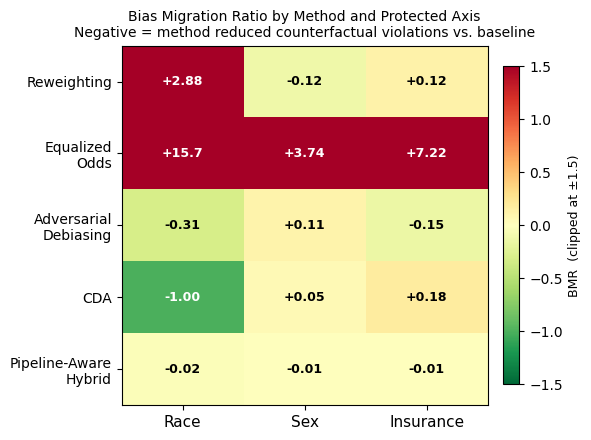

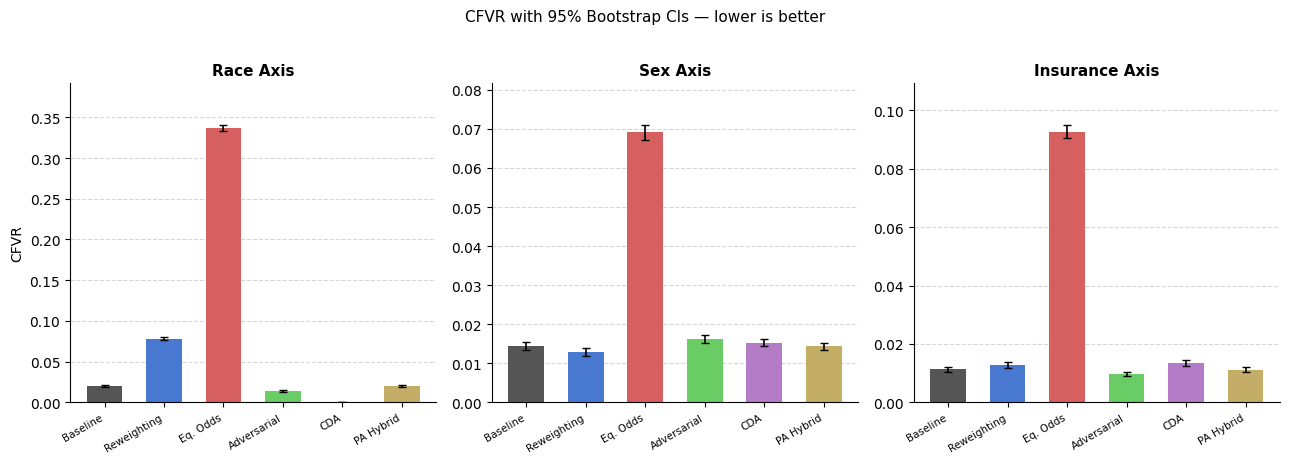

In [36]:
import matplotlib.pyplot as plt
import numpy as np

methods_keys  = ["reweighting", "equalized_odds", "adversarial_debiasing", "cda", "pipeline_aware_hybrid"]
methods_short = ["Reweighting", "Equalized\nOdds", "Adversarial\nDebiasing", "CDA", "Pipeline-Aware\nHybrid"]
method_order  = ["baseline"] + methods_keys
method_labels = ["Baseline", "Reweighting", "Eq. Odds", "Adversarial", "CDA", "PA Hybrid"]

bmr_matrix = np.array([
    [float(matrix.loc[matrix["method"]==m, "bmr_race"].values[0]),
     float(matrix.loc[matrix["method"]==m, "bmr_sex"].values[0]),
     float(matrix.loc[matrix["method"]==m, "bmr_ins"].values[0])]
    for m in methods_keys
])

cfvr_data = {}
for ax_key in ["race", "sex", "insurance"]:
    cfvr_data[ax_key] = {}
    for m in method_order:
        row = stat_df[(stat_df["method"]==m) & (stat_df["axis"]==ax_key)].iloc[0]
        cfvr_data[ax_key][m] = [float(row["cfvr_mean"]), float(row["ci_lo"]), float(row["ci_hi"])]

fig1, ax1 = plt.subplots(figsize=(6, 4.5))
vmin, vmax = -1.5, 1.5
cmap = plt.get_cmap("RdYlGn_r")
im = ax1.imshow(bmr_matrix, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
ax1.set_xticks(range(3))
ax1.set_xticklabels(["Race", "Sex", "Insurance"], fontsize=11)
ax1.set_yticks(range(5))
ax1.set_yticklabels(methods_short, fontsize=10)
for i in range(5):
    for j in range(3):
        val = bmr_matrix[i, j]
        label = f"{val:+.2f}" if abs(val) < 10 else f"{val:+.1f}"
        color = "white" if abs(val) > 0.8 else "black"
        ax1.text(j, i, label, ha="center", va="center", fontsize=9, color=color, fontweight="bold")
cbar = fig1.colorbar(im, ax=ax1, fraction=0.04, pad=0.04)
cbar.set_label("BMR  (clipped at ±1.5)", fontsize=9)
ax1.set_title("Bias Migration Ratio by Method and Protected Axis\n"
              "Negative = method reduced counterfactual violations vs. baseline", fontsize=10)
fig1.tight_layout()
fig1.savefig("/kaggle/working/fig1_bmr_heatmap.png", dpi=150, bbox_inches="tight")

method_colors = ["#555555","#4878CF","#D65F5F","#6ACC65","#B47CC7","#C4AD66"]
ax_keys   = ["race", "sex", "insurance"]
ax_titles = ["Race Axis", "Sex Axis", "Insurance Axis"]
ymaxes    = [max(cfvr_data["race"][m][2] for m in method_order) * 1.15,
             max(cfvr_data["sex"][m][2]  for m in method_order) * 1.15,
             max(cfvr_data["insurance"][m][2] for m in method_order) * 1.15]

fig2, axes2 = plt.subplots(1, 3, figsize=(13, 4.5))
for col, (ak, at, ym) in enumerate(zip(ax_keys, ax_titles, ymaxes)):
    ax = axes2[col]
    for i, m in enumerate(method_order):
        mean, lo, hi = cfvr_data[ak][m]
        ax.bar(i, mean, color=method_colors[i], width=0.6,
               yerr=[[mean-lo],[hi-mean]], capsize=3,
               error_kw={"elinewidth": 1.2, "ecolor": "black"})
    ax.set_xticks(range(len(method_order)))
    ax.set_xticklabels(method_labels, fontsize=7.5, rotation=30, ha="right")
    ax.set_ylim(0, ym)
    ax.set_title(at, fontsize=11, fontweight="bold")
    ax.set_ylabel("CFVR" if col == 0 else "", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig2.suptitle("CFVR with 95% Bootstrap CIs — lower is better", fontsize=11, y=1.02)
fig2.tight_layout()
fig2.savefig("/kaggle/working/fig2_cfvr_bars.png", dpi=150, bbox_inches="tight")
plt.show()


## Figure 3: Pipeline-Aware Pareto Frontier

AUROC vs CFVR tradeoff across lambda values. Each point is one trained model. Top-left = ideal (high accuracy, low counterfactual violations). The baseline is shown for reference.


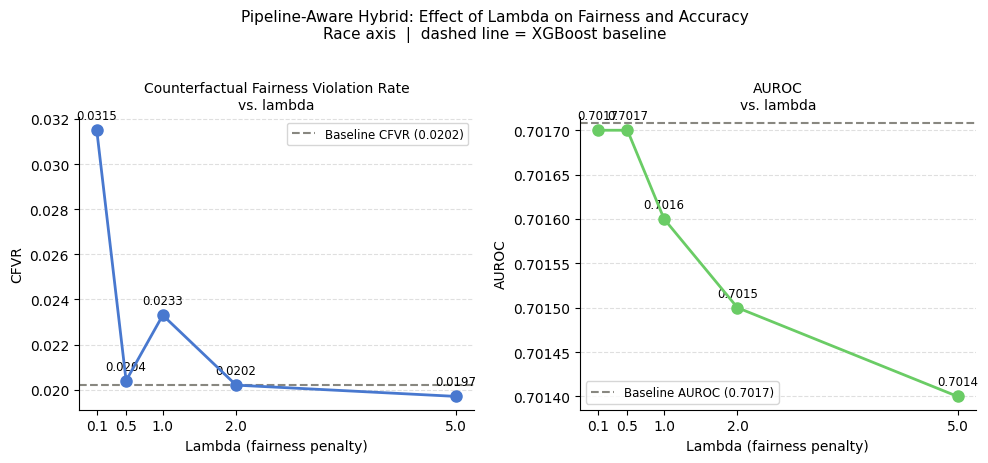

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

pareto_df = pd.read_csv("/kaggle/working/lambda_pareto.csv").sort_values("lambda").reset_index(drop=True)

fig, (ax_cfvr, ax_auc) = plt.subplots(1, 2, figsize=(10, 4.5))

lam = pareto_df["lambda"].values
cfvr = pareto_df["cfvr"].values
auroc = pareto_df["auroc"].values

color = "#4878CF"

ax_cfvr.plot(lam, cfvr, marker="o", color=color, linewidth=2, markersize=8, zorder=5)
ax_cfvr.axhline(cfvr_base, color="#888780", linestyle="--", linewidth=1.5, label=f"Baseline CFVR ({cfvr_base:.4f})")
for x, y in zip(lam, cfvr):
    ax_cfvr.annotate(f"{y:.4f}", xy=(x, y), xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=8.5)
ax_cfvr.set_xlabel("Lambda (fairness penalty)", fontsize=10)
ax_cfvr.set_ylabel("CFVR", fontsize=10)
ax_cfvr.set_title("Counterfactual Fairness Violation Rate\nvs. lambda", fontsize=10)
ax_cfvr.set_xticks(lam)
ax_cfvr.legend(fontsize=8.5)
ax_cfvr.spines["top"].set_visible(False)
ax_cfvr.spines["right"].set_visible(False)
ax_cfvr.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_cfvr.set_axisbelow(True)

ax_auc.plot(lam, auroc, marker="o", color="#6ACC65", linewidth=2, markersize=8, zorder=5)
ax_auc.axhline(auroc_base, color="#888780", linestyle="--", linewidth=1.5, label=f"Baseline AUROC ({auroc_base:.4f})")
for x, y in zip(lam, auroc):
    ax_auc.annotate(f"{y:.4f}", xy=(x, y), xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=8.5)
ax_auc.set_xlabel("Lambda (fairness penalty)", fontsize=10)
ax_auc.set_ylabel("AUROC", fontsize=10)
ax_auc.set_title("AUROC\nvs. lambda", fontsize=10)
ax_auc.set_xticks(lam)
ax_auc.legend(fontsize=8.5)
ax_auc.spines["top"].set_visible(False)
ax_auc.spines["right"].set_visible(False)
ax_auc.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_auc.set_axisbelow(True)

fig.suptitle("Pipeline-Aware Hybrid: Effect of Lambda on Fairness and Accuracy\n"
             "Race axis  |  dashed line = XGBoost baseline", fontsize=11, y=1.02)
fig.tight_layout()
fig.savefig("/kaggle/working/fig3_lambda_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
axes_s2 = {
    "race":      (RACES,      "race_clean"),
    "sex":       (SEXES,      "sex"),
    "insurance": (INS_GROUPS, "insurance_clean"),
}

stage2_rows = []
for ax, (groups, gcol) in axes_s2.items():
    orig = orig_scores["baseline"]
    max_delta = np.zeros(n_val)

    for g in groups:
        if g not in cf_scores["baseline"][ax]:
            continue
        delta = np.abs(orig - cf_scores["baseline"][ax][g])
        max_delta = np.maximum(max_delta, delta)

    print(f"\n{ax.upper()} AXIS")
    print(f"  mean max |Δscore|:   {max_delta.mean():.5f}")
    print(f"  median max |Δscore|: {np.median(max_delta):.5f}")
    print(f"  p95 max |Δscore|:    {np.percentile(max_delta, 95):.5f}")

    for delta_thr in [0.005, 0.01, 0.02, 0.05]:
        cfvr_s2 = round((max_delta > delta_thr).mean(), 4)
        stage2_rows.append({"axis": ax, "delta": delta_thr, "cfvr_stage2": cfvr_s2})
        print(f"  Stage 2 CFVR (|Δscore| > {delta_thr:.3f}): {cfvr_s2:.4f}")

stage2_df = pd.DataFrame(stage2_rows)

stage3_cfvr_lookup = {"race": cfvr_base, "sex": cfvr_base_sex, "insurance": cfvr_base_ins}
print("\nSTAGE 2 vs STAGE 3 (delta=0.01)")
print(f"  {'axis':<12} {'stage2_cfvr':<14} {'stage3_cfvr':<14} absorption")
for ax_name in ["race", "sex", "insurance"]:
    s2 = stage2_df[(stage2_df["axis"]==ax_name) & (stage2_df["delta"]==0.01)]["cfvr_stage2"].values[0]
    s3 = stage3_cfvr_lookup[ax_name]
    absorb = round(1 - s3/s2, 3) if s2 > 0 else float("nan")
    print(f"  {ax_name:<12} {s2:<14.4f} {s3:<14.4f} {absorb:.1%} of score bias absorbed by threshold")

stage2_df.to_parquet("/kaggle/working/stage2_cfvr.parquet", index=False)


RACE AXIS
  mean max |Δscore|:   0.03757
  median max |Δscore|: 0.03169
  p95 max |Δscore|:    0.09711
  Stage 2 CFVR (|Δscore| > 0.005): 0.9050
  Stage 2 CFVR (|Δscore| > 0.010): 0.8779
  Stage 2 CFVR (|Δscore| > 0.020): 0.7632
  Stage 2 CFVR (|Δscore| > 0.050): 0.2459

SEX AXIS
  mean max |Δscore|:   0.01265
  median max |Δscore|: 0.01019
  p95 max |Δscore|:    0.04096
  Stage 2 CFVR (|Δscore| > 0.005): 0.5973
  Stage 2 CFVR (|Δscore| > 0.010): 0.5012
  Stage 2 CFVR (|Δscore| > 0.020): 0.2688
  Stage 2 CFVR (|Δscore| > 0.050): 0.0197

INSURANCE AXIS
  mean max |Δscore|:   0.01274
  median max |Δscore|: 0.01053
  p95 max |Δscore|:    0.03610
  Stage 2 CFVR (|Δscore| > 0.005): 0.6490
  Stage 2 CFVR (|Δscore| > 0.010): 0.5334
  Stage 2 CFVR (|Δscore| > 0.020): 0.2610
  Stage 2 CFVR (|Δscore| > 0.050): 0.0133

STAGE 2 vs STAGE 3 (delta=0.01)
  axis         stage2_cfvr    stage3_cfvr    absorption
  race         0.8779         0.0202         97.7% of score bias absorbed by threshold
  se

## Final Test-Set Evaluation

Everything above was developed and tuned on val. This section is a single, final pass on the held-out test set. No thresholds are re-derived here -- we apply the exact thresholds already fixed above and see how the numbers hold up on data none of the methods have touched.


In [39]:
continuous_methods_test = {
    "baseline":              (score_fn_base, threshold_base),
    "reweighting":           (score_fn_rw,   threshold_rw),
    "adversarial_debiasing": (score_fn_adv,  threshold_adv),
    "cda":                   (score_fn_cda,  threshold_cda),
    "pipeline_aware_hybrid": (score_fn_pa,   threshold_pa),
}

test_scores   = {m: fn(test) for m, (fn, _) in continuous_methods_test.items()}
test_enrolled = {m: (test_scores[m] >= thr).astype(int) for m, (_, thr) in continuous_methods_test.items()}
test_enrolled["equalized_odds"] = predict_fn_eo(test)

test_auroc = {m: roc_auc_score(y_test, s) for m, s in test_scores.items()}

method_order_all = ["baseline", "reweighting", "equalized_odds", "adversarial_debiasing", "cda", "pipeline_aware_hybrid"]
for m in method_order_all:
    auc_str = f"{test_auroc[m]:.4f}" if m in test_auroc else "n/a"
    print(f"{m:25s} enrollment_rate={test_enrolled[m].mean():.3f}  auroc={auc_str}")


baseline                  enrollment_rate=0.096  auroc=0.7007
reweighting               enrollment_rate=0.116  auroc=0.6919
equalized_odds            enrollment_rate=0.342  auroc=n/a
adversarial_debiasing     enrollment_rate=0.101  auroc=0.6850
cda                       enrollment_rate=0.099  auroc=0.6972
pipeline_aware_hybrid     enrollment_rate=0.095  auroc=0.6993


In [40]:
test_race_dfs = {}
for m in method_order_all:
    df = test[["race_clean"]].copy()
    df["enrolled"] = test_enrolled[m]
    df["y_true"] = y_test.values
    test_race_dfs[m] = df

test_dp_ratio_race = {}
for m, df in test_race_dfs.items():
    metrics = compute_fairness_metrics(df, "race_clean", "enrolled", "y_true")
    test_dp_ratio_race[m] = metrics["enrollment_rate"].min() / metrics["enrollment_rate"].max()

cfvr_test_race = {}
for m, (fn, thr) in continuous_methods_test.items():
    cfvr_test_race[m], _ = compute_cfvr(fn, test, thr)
cfvr_test_race["equalized_odds"], _ = cfvr_binary(predict_fn_eo, test)

cfvr_base_test = cfvr_test_race["baseline"]
bmr_test_race = {
    m: round((c - cfvr_base_test) / cfvr_base_test, 4) if cfvr_base_test > 0 else 0.0
    for m, c in cfvr_test_race.items()
}

for m in method_order_all:
    print(f"{m:25s} dp_ratio={test_dp_ratio_race[m]:.3f}  cfvr={cfvr_test_race[m]:.4f}  bmr={bmr_test_race[m]:+.4f}")


baseline                  dp_ratio=0.442  cfvr=0.0206  bmr=+0.0000
reweighting               dp_ratio=0.709  cfvr=0.0783  bmr=+2.8010
equalized_odds            dp_ratio=0.886  cfvr=0.3412  bmr=+15.5631
adversarial_debiasing     dp_ratio=0.508  cfvr=0.0127  bmr=-0.3835
cda                       dp_ratio=0.489  cfvr=0.0000  bmr=-1.0000
pipeline_aware_hybrid     dp_ratio=0.442  cfvr=0.0202  bmr=-0.0194


In [41]:
dp_test_sex = {m: dp_ratio_from_enrolled(test_enrolled[m], test["sex"]) for m in test_enrolled}

cfvr_test_sex = {
    m: compute_cfvr_attr(fn, test, thr, "sex", "sex_enc", SEXES, SEX_TO_ENC)
    for m, (fn, thr) in continuous_methods_test.items()
}
cfvr_test_sex["equalized_odds"] = cfvr_binary_attr(predict_fn_eo, test, "sex", "sex_enc", SEXES, SEX_TO_ENC)

cfvr_base_test_sex = cfvr_test_sex["baseline"]
bmr_test_sex = {
    m: round((c - cfvr_base_test_sex) / cfvr_base_test_sex, 4) if cfvr_base_test_sex > 0 else 0.0
    for m, c in cfvr_test_sex.items()
}

for m in method_order_all:
    print(f"{m:25s} dp_ratio={dp_test_sex[m]:.3f}  cfvr={cfvr_test_sex[m]:.4f}  bmr={bmr_test_sex[m]:+.4f}")


baseline                  dp_ratio=0.820  cfvr=0.0138  bmr=+0.0000
reweighting               dp_ratio=0.842  cfvr=0.0127  bmr=-0.0797
equalized_odds            dp_ratio=0.836  cfvr=0.0716  bmr=+4.1884
adversarial_debiasing     dp_ratio=0.824  cfvr=0.0156  bmr=+0.1304
cda                       dp_ratio=0.839  cfvr=0.0142  bmr=+0.0290
pipeline_aware_hybrid     dp_ratio=0.824  cfvr=0.0136  bmr=-0.0145


In [42]:
dp_test_ins = {m: dp_ratio_from_enrolled(test_enrolled[m], test["insurance_clean"]) for m in test_enrolled}

cfvr_test_ins = {
    m: compute_cfvr_attr(fn, test, thr, "insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC)
    for m, (fn, thr) in continuous_methods_test.items()
}
cfvr_test_ins["equalized_odds"] = cfvr_binary_attr(predict_fn_eo, test, "insurance_clean", "insurance_enc", INS_GROUPS, INS_TO_ENC)

cfvr_base_test_ins = cfvr_test_ins["baseline"]
bmr_test_ins = {
    m: round((c - cfvr_base_test_ins) / cfvr_base_test_ins, 4) if cfvr_base_test_ins > 0 else 0.0
    for m, c in cfvr_test_ins.items()
}

for m in method_order_all:
    print(f"{m:25s} dp_ratio={dp_test_ins[m]:.3f}  cfvr={cfvr_test_ins[m]:.4f}  bmr={bmr_test_ins[m]:+.4f}")


baseline                  dp_ratio=0.506  cfvr=0.0111  bmr=+0.0000
reweighting               dp_ratio=0.535  cfvr=0.0132  bmr=+0.1892
equalized_odds            dp_ratio=0.664  cfvr=0.0918  bmr=+7.2703
adversarial_debiasing     dp_ratio=0.473  cfvr=0.0094  bmr=-0.1532
cda                       dp_ratio=0.496  cfvr=0.0120  bmr=+0.0811
pipeline_aware_hybrid     dp_ratio=0.511  cfvr=0.0110  bmr=-0.0090


In [43]:
test_matrix = pd.DataFrame([
    {
        "method":        m,
        "dp_ratio_race": round(test_dp_ratio_race[m], 3),
        "cfvr_race":     cfvr_test_race[m],
        "bmr_race":      bmr_test_race[m],
        "dp_ratio_sex":  round(dp_test_sex[m], 3),
        "cfvr_sex":      cfvr_test_sex[m],
        "bmr_sex":       bmr_test_sex[m],
        "dp_ratio_ins":  round(dp_test_ins[m], 3),
        "cfvr_ins":      cfvr_test_ins[m],
        "bmr_ins":       bmr_test_ins[m],
        "auroc":         round(test_auroc[m], 4) if m in test_auroc else float("nan"),
    }
    for m in method_order_all
])

print("TEST SET -- RACE AXIS")
print(test_matrix[["method", "dp_ratio_race", "cfvr_race", "bmr_race", "auroc"]].to_string(index=False))

print("\nTEST SET -- SEX AXIS")
print(test_matrix[["method", "dp_ratio_sex", "cfvr_sex", "bmr_sex"]].to_string(index=False))

print("\nTEST SET -- INSURANCE AXIS")
print(test_matrix[["method", "dp_ratio_ins", "cfvr_ins", "bmr_ins"]].to_string(index=False))

test_matrix.to_parquet("/kaggle/working/test_full_experimental_matrix.parquet", index=False)


TEST SET -- RACE AXIS
               method  dp_ratio_race  cfvr_race  bmr_race  auroc
             baseline          0.442     0.0206    0.0000 0.7007
          reweighting          0.709     0.0783    2.8010 0.6919
       equalized_odds          0.886     0.3412   15.5631    NaN
adversarial_debiasing          0.508     0.0127   -0.3835 0.6850
                  cda          0.489     0.0000   -1.0000 0.6972
pipeline_aware_hybrid          0.442     0.0202   -0.0194 0.6993

TEST SET -- SEX AXIS
               method  dp_ratio_sex  cfvr_sex  bmr_sex
             baseline         0.820    0.0138   0.0000
          reweighting         0.842    0.0127  -0.0797
       equalized_odds         0.836    0.0716   4.1884
adversarial_debiasing         0.824    0.0156   0.1304
                  cda         0.839    0.0142   0.0290
pipeline_aware_hybrid         0.824    0.0136  -0.0145

TEST SET -- INSURANCE AXIS
               method  dp_ratio_ins  cfvr_ins  bmr_ins
             baseline         0.5

In [44]:
n_test = len(test)

orig_scores_test = {m: fn(test) for m, (fn, _) in continuous_methods_test.items()}
eo_orig_test = test_enrolled["equalized_odds"].copy()

cf_scores_test = {m: {ax: {} for ax in axes_cfg} for m in continuous_methods_test}
cf_eo_test = {ax: {} for ax in axes_cfg}

for ax, (gcol, ecol, groups, enc_map) in axes_cfg.items():
    for g in groups:
        mask = (test[gcol].values != g)
        if mask.sum() == 0:
            continue
        cf = test.copy()
        cf.loc[cf.index[mask], gcol] = g
        cf.loc[cf.index[mask], ecol] = enc_map[g]
        for m, (fn, _) in continuous_methods_test.items():
            cf_scores_test[m][ax][g] = fn(cf)
        cf_eo_test[ax][g] = predict_fn_eo(cf)


In [45]:
N_BOOTSTRAP = 1000
np.random.seed(42)

all_method_keys_test = list(continuous_methods_test) + ["equalized_odds"]
boot_cfvr_test = {m: {ax: np.zeros(N_BOOTSTRAP) for ax in axes_cfg} for m in all_method_keys_test}

for b in range(N_BOOTSTRAP):
    idx = np.random.choice(n_test, n_test, replace=True)

    for ax, (gcol, ecol, groups, enc_map) in axes_cfg.items():
        orig_groups = test[gcol].values[idx]

        for m, (fn, thr) in continuous_methods_test.items():
            orig_enr = (orig_scores_test[m][idx] >= thr).astype(int)
            any_flip = np.zeros(len(idx), dtype=int)
            for g in groups:
                if g not in cf_scores_test[m][ax]:
                    continue
                mask_g  = (orig_groups != g)
                cf_enr  = (cf_scores_test[m][ax][g][idx] >= thr).astype(int)
                flipped = ((cf_enr != orig_enr) & mask_g).astype(int)
                any_flip = np.maximum(any_flip, flipped)
            boot_cfvr_test[m][ax][b] = any_flip.mean()

        orig_enr_eo = eo_orig_test[idx]
        any_flip_eo = np.zeros(len(idx), dtype=int)
        for g in groups:
            if g not in cf_eo_test[ax]:
                continue
            mask_g      = (orig_groups != g)
            cf_enr_eo   = cf_eo_test[ax][g][idx]
            flipped     = ((cf_enr_eo != orig_enr_eo) & mask_g).astype(int)
            any_flip_eo = np.maximum(any_flip_eo, flipped)
        boot_cfvr_test["equalized_odds"][ax][b] = any_flip_eo.mean()

    if (b + 1) % 100 == 0:
        print(f"bootstrap {b+1}/{N_BOOTSTRAP}")


bootstrap 100/1000
bootstrap 200/1000
bootstrap 300/1000
bootstrap 400/1000
bootstrap 500/1000
bootstrap 600/1000
bootstrap 700/1000
bootstrap 800/1000
bootstrap 900/1000
bootstrap 1000/1000


In [46]:
stat_rows_test = []
for ax in axes_list:
    base_boot = boot_cfvr_test["baseline"][ax]
    for m in method_order:
        m_boot  = boot_cfvr_test[m][ax]
        ci_lo, ci_hi = np.percentile(m_boot, [2.5, 97.5])

        if m == "baseline":
            p_val, h = float("nan"), 0.0
            diff_ci_lo = diff_ci_hi = 0.0
        else:
            diff = base_boot - m_boot
            diff_ci_lo, diff_ci_hi = np.percentile(diff, [2.5, 97.5])
            p_val = min(2 * min((diff <= 0).mean(), (diff >= 0).mean()), 1.0)
            h = cohens_h(base_boot.mean(), m_boot.mean())

        stat_rows_test.append({
            "method":     m,
            "axis":       ax,
            "cfvr_mean":  round(float(m_boot.mean()), 4),
            "ci_lo":      round(float(ci_lo), 4),
            "ci_hi":      round(float(ci_hi), 4),
            "diff_ci_lo": round(float(diff_ci_lo), 4),
            "diff_ci_hi": round(float(diff_ci_hi), 4),
            "p_value":    round(p_val, 6) if not (p_val != p_val) else float("nan"),
            "cohens_h":   round(h, 3),
        })

stat_df_test = pd.DataFrame(stat_rows_test)

mask = stat_df_test["method"] != "baseline"
pvals = stat_df_test.loc[mask, "p_value"].fillna(1.0).values
_, p_adj, _, _ = multipletests(pvals, method="fdr_bh")
stat_df_test.loc[mask, "p_adj"] = p_adj.round(6)

for ax in axes_list:
    print(f"\nTEST SET -- {ax.upper()} AXIS")
    sub = stat_df_test[stat_df_test["axis"] == ax][
        ["method", "cfvr_mean", "ci_lo", "ci_hi", "diff_ci_lo", "diff_ci_hi", "p_adj", "cohens_h"]
    ]
    print(sub.to_string(index=False))

stat_df_test.to_parquet("/kaggle/working/statistical_results_test.parquet", index=False)



TEST SET -- RACE AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi  p_adj  cohens_h
             baseline     0.0206 0.0194 0.0217      0.0000      0.0000    NaN     0.000
          reweighting     0.0783 0.0761 0.0804     -0.0598     -0.0555    0.0    -0.279
       equalized_odds     0.3393 0.3353 0.3433     -0.3230     -0.3146    0.0    -0.956
adversarial_debiasing     0.0127 0.0118 0.0136      0.0064      0.0093    0.0     0.062
                  cda     0.0000 0.0000 0.0000      0.0194      0.0217    0.0     0.288
pipeline_aware_hybrid     0.0202 0.0190 0.0213      0.0003      0.0006    0.0     0.003

TEST SET -- SEX AXIS
               method  cfvr_mean  ci_lo  ci_hi  diff_ci_lo  diff_ci_hi    p_adj  cohens_h
             baseline     0.0138 0.0129 0.0147      0.0000      0.0000      NaN     0.000
          reweighting     0.0126 0.0117 0.0135      0.0000      0.0024 0.067500     0.010
       equalized_odds     0.0719 0.0698 0.0739     -0.0604     -0.055

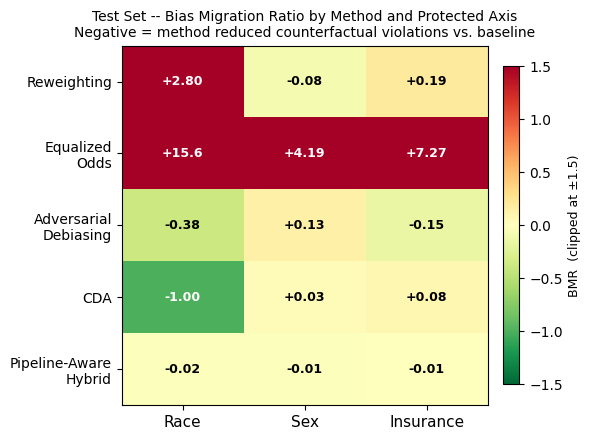

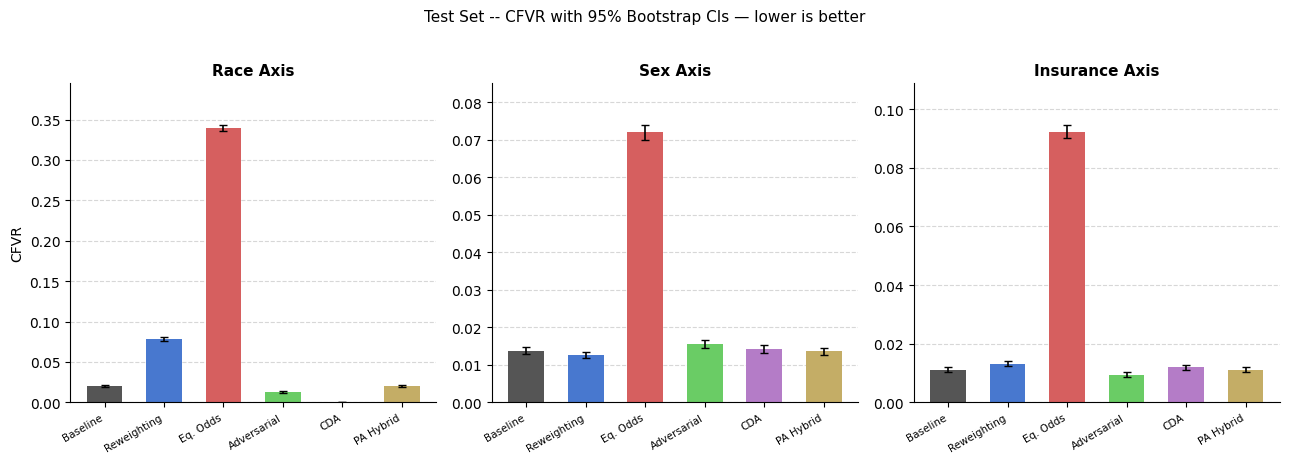

In [47]:
methods_keys_t  = ["reweighting", "equalized_odds", "adversarial_debiasing", "cda", "pipeline_aware_hybrid"]
methods_short_t = ["Reweighting", "Equalized\nOdds", "Adversarial\nDebiasing", "CDA", "Pipeline-Aware\nHybrid"]
method_order_t  = ["baseline"] + methods_keys_t
method_labels_t = ["Baseline", "Reweighting", "Eq. Odds", "Adversarial", "CDA", "PA Hybrid"]

bmr_matrix_test = np.array([
    [float(test_matrix.loc[test_matrix["method"]==m, "bmr_race"].values[0]),
     float(test_matrix.loc[test_matrix["method"]==m, "bmr_sex"].values[0]),
     float(test_matrix.loc[test_matrix["method"]==m, "bmr_ins"].values[0])]
    for m in methods_keys_t
])

cfvr_data_test = {}
for ax_key in ["race", "sex", "insurance"]:
    cfvr_data_test[ax_key] = {}
    for m in method_order_t:
        row = stat_df_test[(stat_df_test["method"]==m) & (stat_df_test["axis"]==ax_key)].iloc[0]
        cfvr_data_test[ax_key][m] = [float(row["cfvr_mean"]), float(row["ci_lo"]), float(row["ci_hi"])]

fig1t, ax1t = plt.subplots(figsize=(6, 4.5))
vmin, vmax = -1.5, 1.5
cmap = plt.get_cmap("RdYlGn_r")
im = ax1t.imshow(bmr_matrix_test, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
ax1t.set_xticks(range(3))
ax1t.set_xticklabels(["Race", "Sex", "Insurance"], fontsize=11)
ax1t.set_yticks(range(5))
ax1t.set_yticklabels(methods_short_t, fontsize=10)
for i in range(5):
    for j in range(3):
        v = bmr_matrix_test[i, j]
        label = f"{v:+.2f}" if abs(v) < 10 else f"{v:+.1f}"
        color = "white" if abs(v) > 0.8 else "black"
        ax1t.text(j, i, label, ha="center", va="center", fontsize=9, color=color, fontweight="bold")
cbar = fig1t.colorbar(im, ax=ax1t, fraction=0.04, pad=0.04)
cbar.set_label("BMR  (clipped at \u00b11.5)", fontsize=9)
ax1t.set_title("Test Set -- Bias Migration Ratio by Method and Protected Axis\n"
               "Negative = method reduced counterfactual violations vs. baseline", fontsize=10)
fig1t.tight_layout()
fig1t.savefig("/kaggle/working/fig1_bmr_heatmap_test.png", dpi=150, bbox_inches="tight")

method_colors = ["#555555","#4878CF","#D65F5F","#6ACC65","#B47CC7","#C4AD66"]
ax_keys   = ["race", "sex", "insurance"]
ax_titles = ["Race Axis", "Sex Axis", "Insurance Axis"]
ymaxes    = [max(cfvr_data_test["race"][m][2] for m in method_order_t) * 1.15,
             max(cfvr_data_test["sex"][m][2]  for m in method_order_t) * 1.15,
             max(cfvr_data_test["insurance"][m][2] for m in method_order_t) * 1.15]

fig2t, axes2t = plt.subplots(1, 3, figsize=(13, 4.5))
for col, (ak, at, ym) in enumerate(zip(ax_keys, ax_titles, ymaxes)):
    ax = axes2t[col]
    for i, m in enumerate(method_order_t):
        mean, lo, hi = cfvr_data_test[ak][m]
        ax.bar(i, mean, color=method_colors[i], width=0.6,
               yerr=[[mean-lo],[hi-mean]], capsize=3,
               error_kw={"elinewidth": 1.2, "ecolor": "black"})
    ax.set_xticks(range(len(method_order_t)))
    ax.set_xticklabels(method_labels_t, fontsize=7.5, rotation=30, ha="right")
    ax.set_ylim(0, ym)
    ax.set_title(at, fontsize=11, fontweight="bold")
    ax.set_ylabel("CFVR" if col == 0 else "", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig2t.suptitle("Test Set -- CFVR with 95% Bootstrap CIs \u2014 lower is better", fontsize=11, y=1.02)
fig2t.tight_layout()
fig2t.savefig("/kaggle/working/fig2_cfvr_bars_test.png", dpi=150, bbox_inches="tight")
plt.show()


In [48]:
print("VAL vs TEST -- race axis dp_ratio and CFVR")
for m in method_order_all:
    dp_val = matrix.loc[matrix["method"]==m, "dp_ratio_race"].values[0]
    dp_tst = test_matrix.loc[test_matrix["method"]==m, "dp_ratio_race"].values[0]
    cf_val = matrix.loc[matrix["method"]==m, "cfvr_race"].values[0]
    cf_tst = test_matrix.loc[test_matrix["method"]==m, "cfvr_race"].values[0]
    print(f"{m:25s} dp_ratio: val={dp_val:.3f} test={dp_tst:.3f}   cfvr: val={cf_val:.4f} test={cf_tst:.4f}")


VAL vs TEST -- race axis dp_ratio and CFVR
baseline                  dp_ratio: val=0.360 test=0.442   cfvr: val=0.0202 test=0.0206
reweighting               dp_ratio: val=0.613 test=0.709   cfvr: val=0.0784 test=0.0783
equalized_odds            dp_ratio: val=0.912 test=0.886   cfvr: val=0.3370 test=0.3412
adversarial_debiasing     dp_ratio: val=0.473 test=0.508   cfvr: val=0.0140 test=0.0127
cda                       dp_ratio: val=0.418 test=0.489   cfvr: val=0.0000 test=0.0000
pipeline_aware_hybrid     dp_ratio: val=0.360 test=0.442   cfvr: val=0.0197 test=0.0202


In [49]:
max_delta_test = {}
for ax, (groups, gcol) in axes_s2.items():
    orig = orig_scores_test["baseline"]
    md_ = np.zeros(n_test)
    for g in groups:
        if g not in cf_scores_test["baseline"][ax]:
            continue
        delta = np.abs(orig - cf_scores_test["baseline"][ax][g])
        md_ = np.maximum(md_, delta)
    max_delta_test[ax] = md_

stage2_rows_test = []
for ax, md_ in max_delta_test.items():
    for delta_thr in [0.005, 0.01, 0.02, 0.05]:
        cfvr_s2 = round((md_ > delta_thr).mean(), 4)
        stage2_rows_test.append({"axis": ax, "delta": delta_thr, "cfvr_stage2": cfvr_s2})

stage2_df_test = pd.DataFrame(stage2_rows_test)

stage3_cfvr_lookup_test = {
    "race": cfvr_test_race["baseline"],
    "sex": cfvr_test_sex["baseline"],
    "insurance": cfvr_test_ins["baseline"],
}
print("TEST SET -- STAGE 2 vs STAGE 3 (delta=0.01)")
for ax_name in ["race", "sex", "insurance"]:
    s2 = stage2_df_test[(stage2_df_test["axis"]==ax_name) & (stage2_df_test["delta"]==0.01)]["cfvr_stage2"].values[0]
    s3 = stage3_cfvr_lookup_test[ax_name]
    absorb = round(1 - s3/s2, 3) if s2 > 0 else float("nan")
    print(f"  {ax_name:<12} {s2:<14.4f} {s3:<14.4f} {absorb:.1%} of score bias absorbed by threshold")

stage2_df_test.to_parquet("/kaggle/working/stage2_cfvr_test.parquet", index=False)


TEST SET -- STAGE 2 vs STAGE 3 (delta=0.01)
  race         0.8772         0.0206         97.7% of score bias absorbed by threshold
  sex          0.5034         0.0138         97.3% of score bias absorbed by threshold
  insurance    0.5329         0.0111         97.9% of score bias absorbed by threshold
